In [1]:
# Visualize the final event-aligned features, matched comparisons, and macro conditions.
# Save report-ready figures by feature family.


In [2]:
import sys as _sys
from pathlib import Path as _Path
_UTILS_ROOT = next(path for path in (_Path.cwd().resolve(), *_Path.cwd().resolve().parents)
                   if (path / "notebook_utils.py").is_file())
if str(_UTILS_ROOT) not in _sys.path:
    _sys.path.insert(0, str(_UTILS_ROOT))
from notebook_utils import project_paths, file_hash, safe_divide
from project_config import FINANCIAL_COLUMNS as financial_columns, MARKET_COLUMNS as market_columns, ORIGINAL_COLUMNS as original_columns, RATIO_FORMULAS as ratio_formulas, RATIO_COLUMNS as ratio_columns
from pathlib import Path
import ast
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
try:
    from IPython.display import display, Image
    from IPython import get_ipython
except ImportError:
    display = None

ROOT = Path.cwd().resolve()
if not (ROOT / "data/processed/modeling_dataset_unprocessed.csv").exists():
    ROOT = ROOT.parent
PROCESSED = project_paths(ROOT).processed
FIGURES = ROOT / "artifacts" / "15_visualize_event_aligned_data"
FIGURES.mkdir(parents=True, exist_ok=True)
DPI = 180
MIN_CORRELATION_PAIRS = 30
MAX_MARKET_AGE_DAYS = 45
KEYS = ["company_id", "prediction_date"]
GROUP_NAMES = {0: "Non-bankrupt", 1: "Bankrupt"}
COLORS = {0: "#3979a8", 1: "#b35a46"}
saved_figures = []
input_hashes = {}


def read_literal(filename, name):
    path = ROOT / "notebooks" / filename
    input_hashes[path] = file_hash(path)
    notebook = json.loads(path.read_text(encoding="utf-8"))
    for cell in notebook["cells"]:
        if cell["cell_type"] != "code": continue
        for node in ast.parse("".join(cell["source"])).body:
            if isinstance(node, ast.Assign) and any(isinstance(t, ast.Name) and t.id == name for t in node.targets):
                return ast.literal_eval(node.value)
    raise ValueError(f"Missing {name} in {filename}")

model_path = PROCESSED / "modeling_dataset_unprocessed.csv"
input_hashes[model_path] = file_hash(model_path)
model = pd.read_csv(model_path, dtype={"company_id": "string"})
model_before = model.copy(deep=True)
if model.empty or model.duplicated(KEYS).any() or not model.target.isin([0, 1]).all():
    raise ValueError("Require unique nonempty company-events and a binary target")
prediction_dates = pd.to_datetime(model.prediction_date, errors="raise").astype("datetime64[ns]")
FINANCIAL_REPORTING_LAG_DAYS = 90
ratio_features = {
    "derived_debt_to_assets": "Debt / assets", "derived_current_ratio": "Current ratio",
    "derived_cash_to_assets": "Cash / assets", "derived_ebit_margin": "EBIT margin",
    "derived_ebitda_margin": "EBITDA margin", "derived_interest_coverage": "Interest coverage",
    "derived_operating_cash_flow_to_debt": "Operating cash flow / debt",
}
trend_market_features = {
    "trend_total_assets_growth_1y": "One-year asset growth", "trend_revenue_growth_1y": "One-year revenue growth",
    "trend_total_debt_growth_3y": "Three-year debt growth", "market_return_12m": "12-month stock return",
    "market_volatility_12m": "12-month volatility (annualized)", "market_maximum_drawdown_12m": "12-month maximum drawdown",
}
comparison_features = ratio_features | trend_market_features
missing = sorted(set(comparison_features) - set(model.columns))
if missing: raise ValueError(f"Missing comparison features: {missing}")
feature_columns = [c for c in model if c.startswith(("original_", "derived_", "trend_", "market_", "macro_"))]
if not all(pd.api.types.is_numeric_dtype(model[c]) for c in feature_columns):
    raise ValueError("Nonnumeric feature columns require upstream correction")
if np.isinf(model[feature_columns].to_numpy(dtype=float)).any():
    raise ValueError("Infinite features require upstream correction")
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "figure.facecolor": "white", "savefig.facecolor": "white"})

# Display transforms are monotone; their scales never modify source data.
def finite_values(column, target):
    values = model.loc[model.target.eq(target), column].to_numpy(dtype=float)
    return values[np.isfinite(values)]

def display_scale(values):
    values = np.asarray(values, dtype=float)
    nonzero = np.abs(values[np.isfinite(values) & (values != 0)])
    return float(np.median(nonzero)) if len(nonzero) else 1.

def save_figure(fig, filename, note):
    fig.text(.5, .008, note, ha="center", va="bottom", fontsize=9, color="#475467", wrap=True)
    path = FIGURES / filename
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    plt.close(fig)
    saved_figures.append(path)
    if display is not None and get_ipython() is not None:
        display(Image(filename=str(path), width=1100))

# Keep every matching link, then retain pairs whose two company-events are in the dataset.
pair_records = {}
for records in model.metadata_matching_records_json:
    for record in json.loads(records):
        pair_id = record["matching_pair_id"]
        if pair_id in pair_records and pair_records[pair_id] != record:
            raise ValueError("Conflicting copies of a matching pair")
        pair_records[pair_id] = record
pairs = pd.DataFrame(pair_records.values())
event_keys = {(r.company_id, pd.Timestamp(r.prediction_date)): i for i, r in model.iterrows()}
bank_indices = []
control_indices = []
for record in pairs.to_dict("records"):
    bank_key = (record["bankrupt_company_id"], pd.Timestamp(record["bankrupt_prediction_date"]))
    control_key = (record["control_company_id"], pd.Timestamp(record["control_pseudo_event_date"]))
    if bank_key in event_keys and control_key in event_keys:
        bank_indices.append(event_keys[bank_key]); control_indices.append(event_keys[control_key])
retained_pair_indices = pd.DataFrame({"bank_index": bank_indices, "control_index": control_indices})
if retained_pair_indices.empty: raise ValueError("No retained matched pairs")
if not model.loc[bank_indices, "target"].eq(1).all() or not model.loc[control_indices, "target"].eq(0).all():
    raise ValueError("Invalid matched roles")
matching_counts = retained_pair_indices.groupby("bank_index").control_index.nunique()


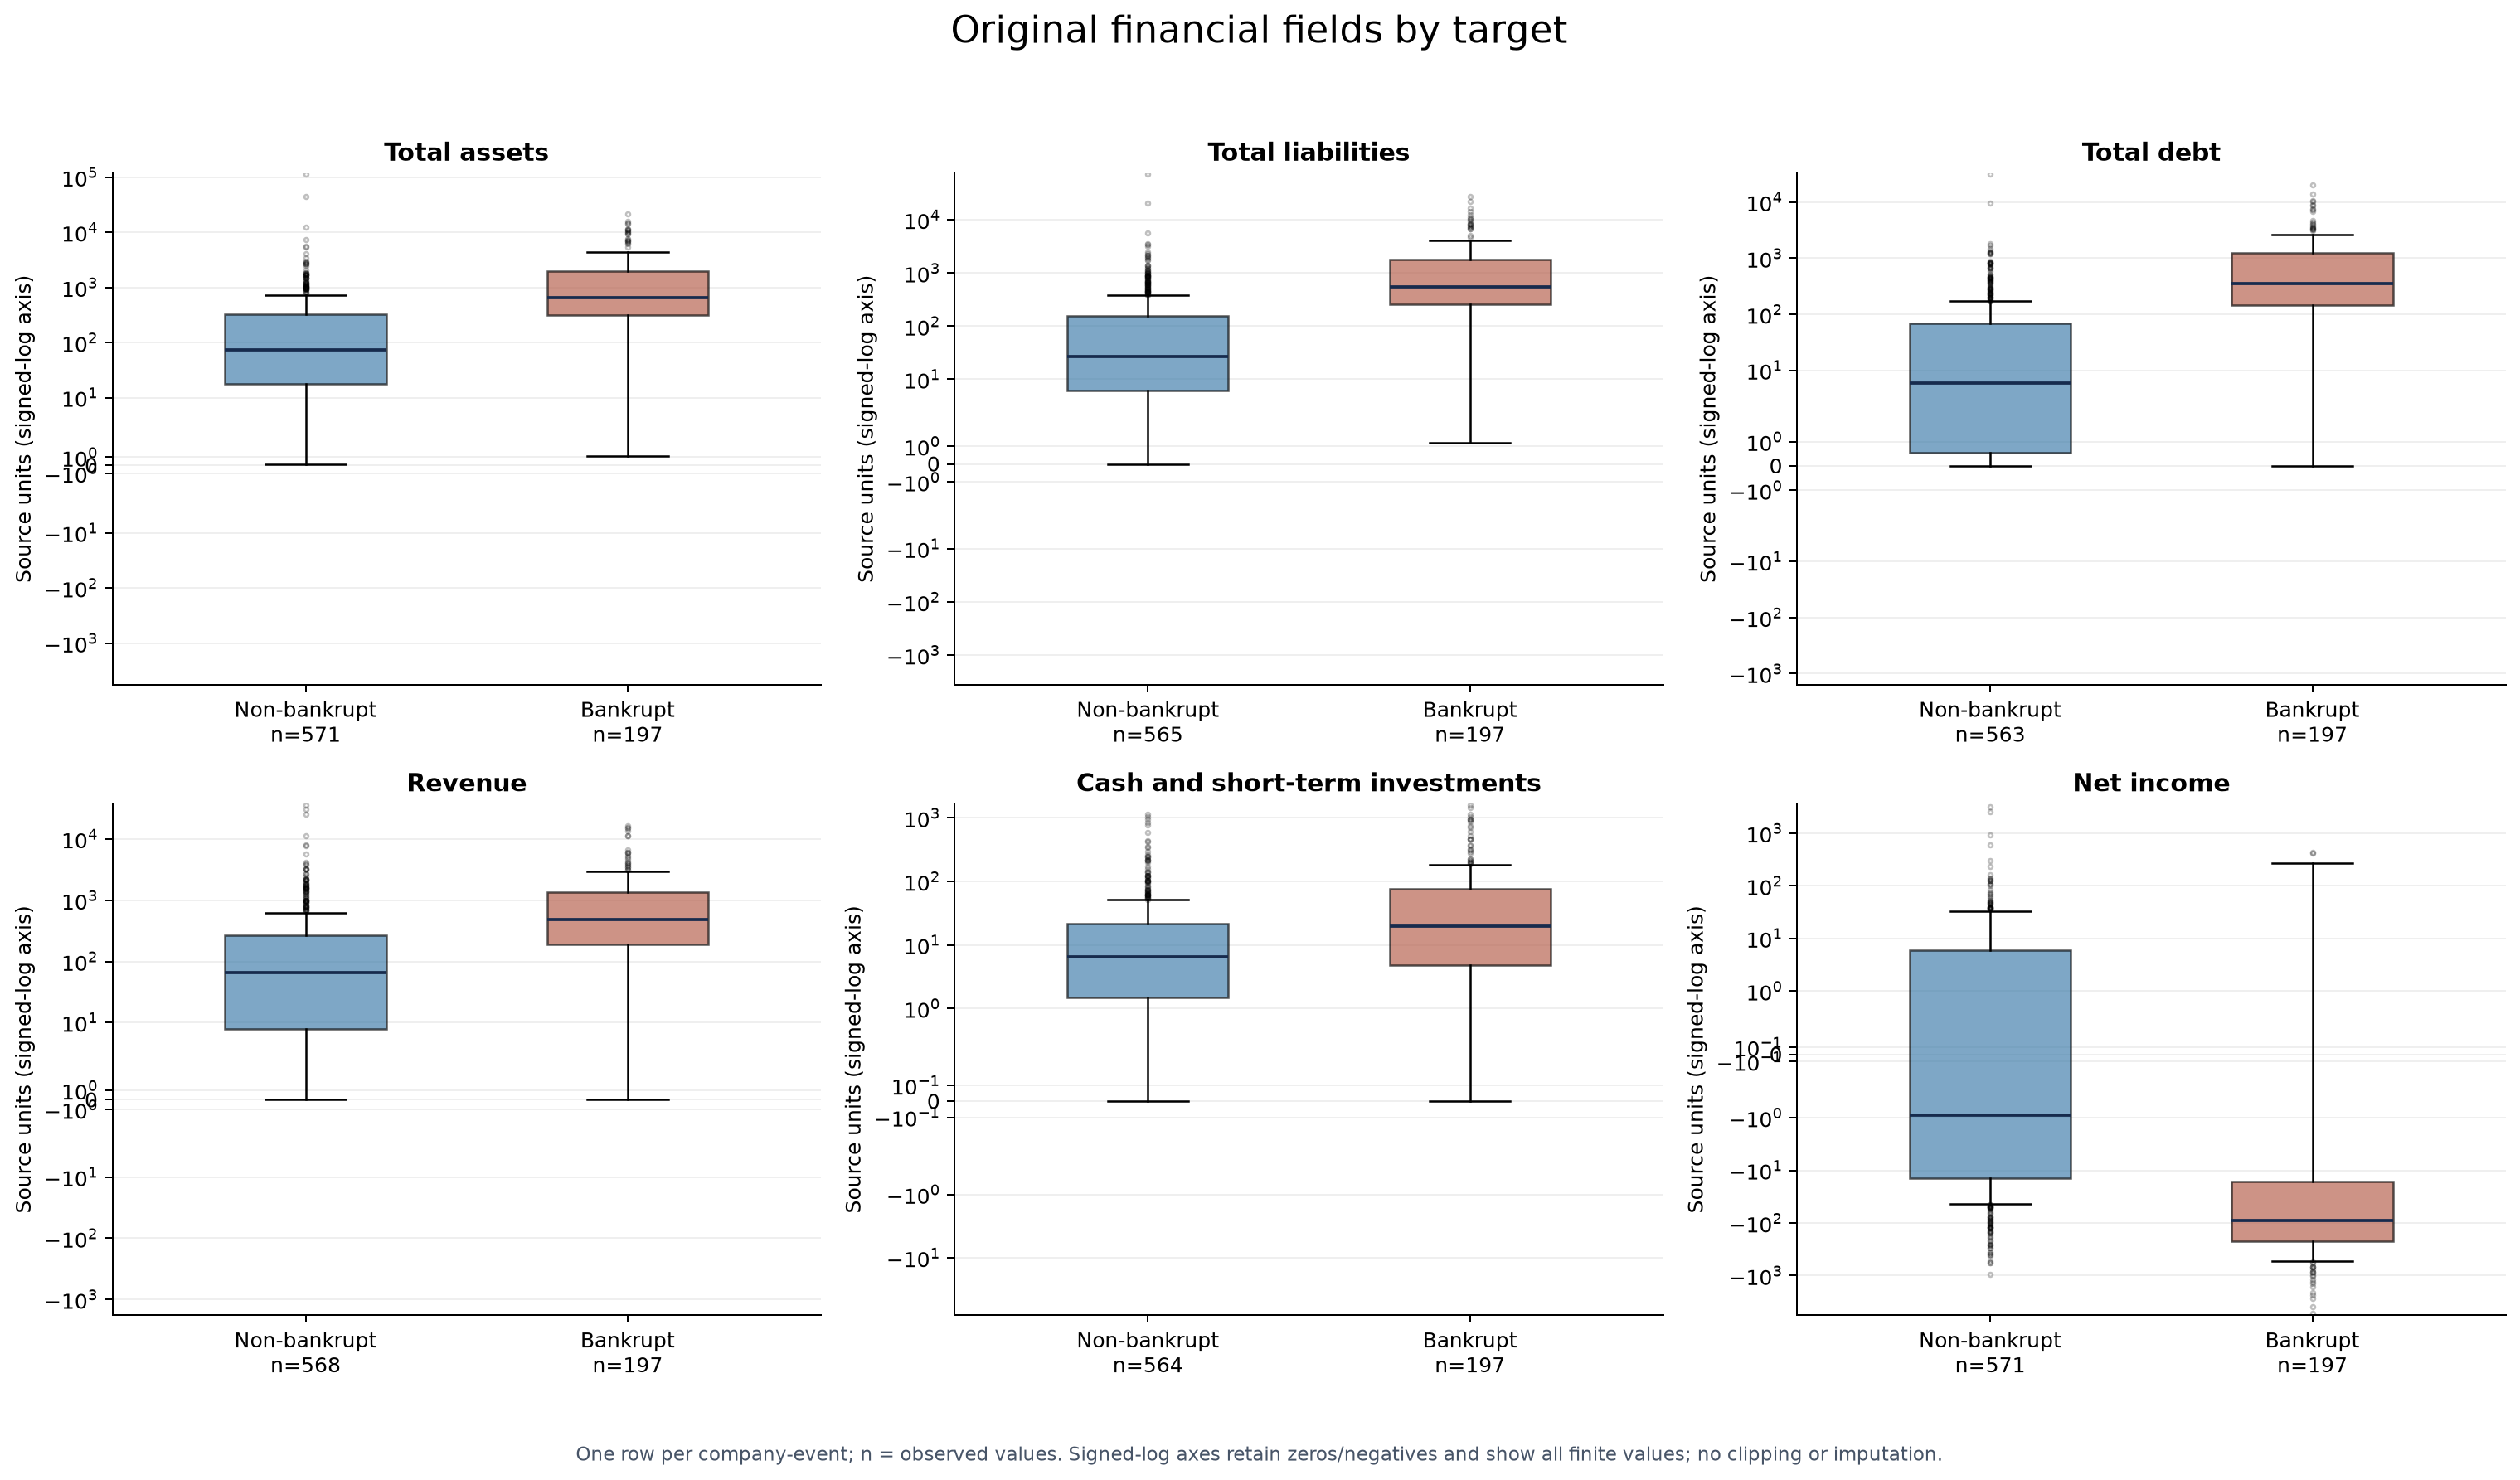

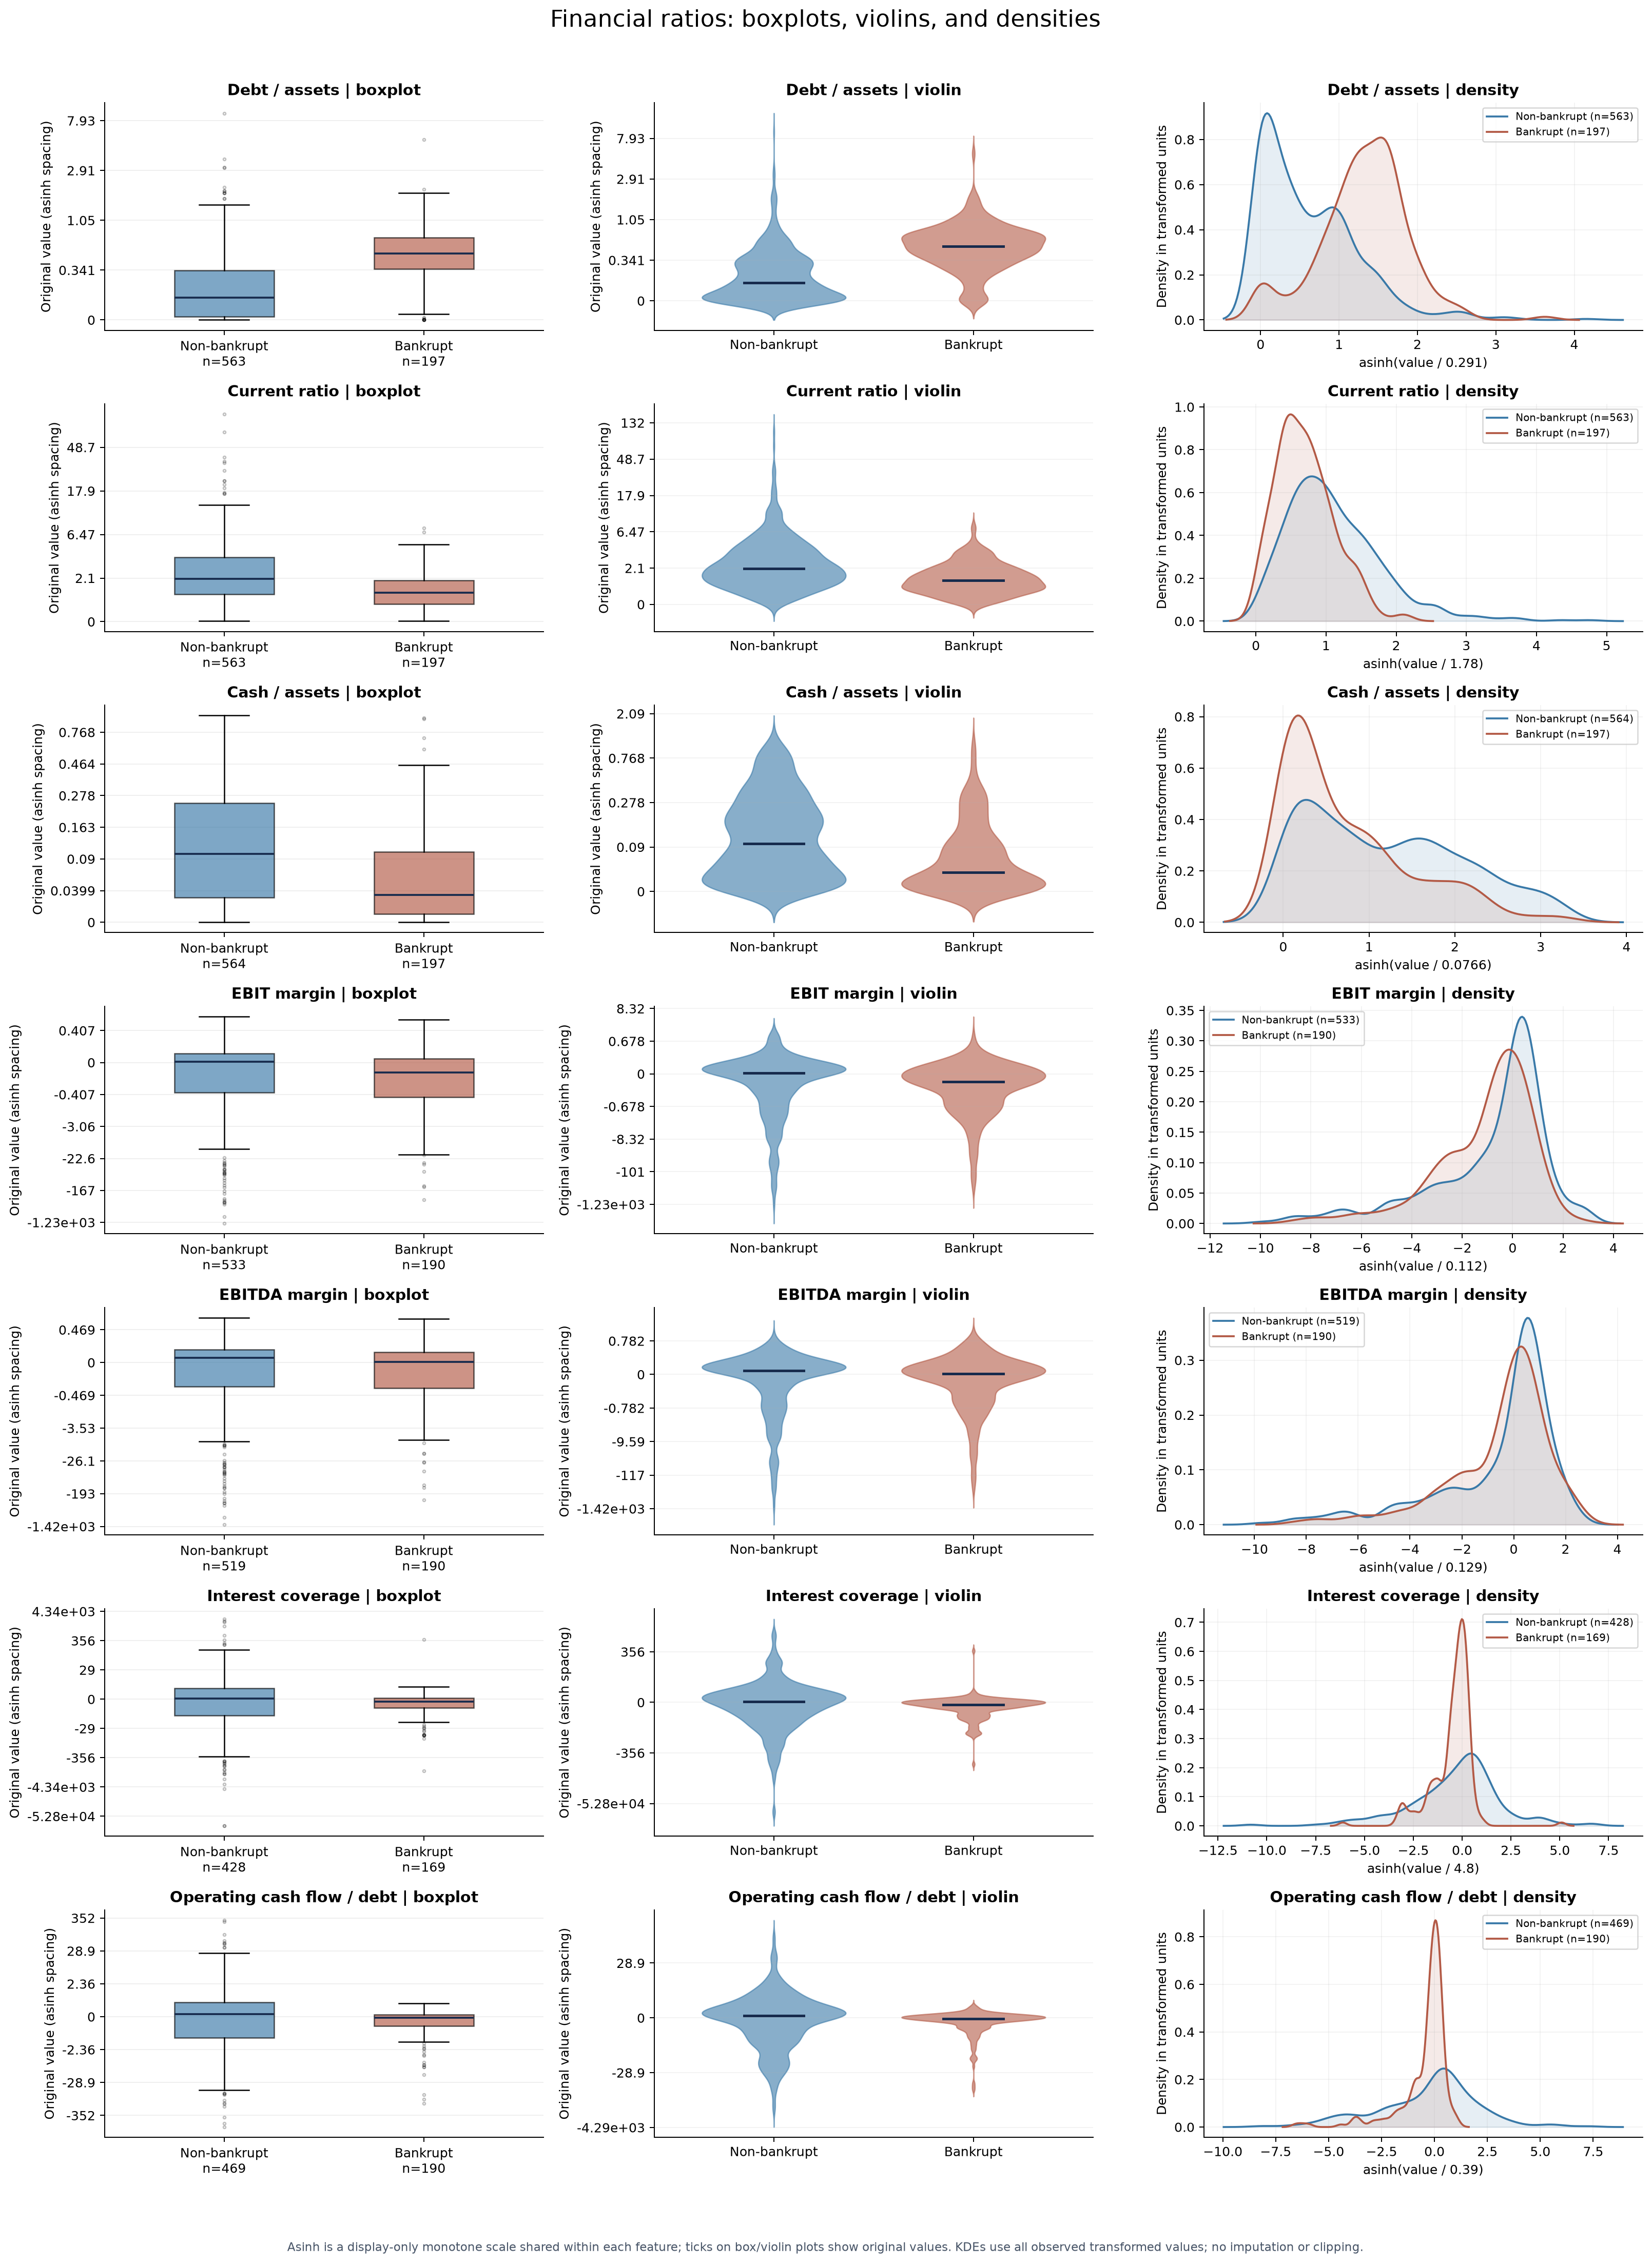

In [3]:
# Original financial distributions retain valid negative values on signed-log axes.
financial_examples = {
    "original_total_assets": "Total assets", "original_total_liabilities": "Total liabilities",
    "original_total_debt": "Total debt", "original_revenue": "Revenue",
    "original_cash_short_term_investments": "Cash and short-term investments", "original_net_income": "Net income",
}

def grouped_boxplot(ax, column, title, transformed=False):
    groups = [finite_values(column, target) for target in [0, 1]]
    scale = display_scale(np.concatenate(groups))
    values = [np.arcsinh(group / scale) if transformed else group for group in groups]
    positions = [i for i, group in enumerate(values) if len(group)]
    if positions:
        boxes = ax.boxplot([values[i] for i in positions], positions=positions, widths=.5, patch_artist=True,
                           showfliers=True, flierprops={"markersize": 2, "alpha": .25},
                           medianprops={"color": "#172b4d", "linewidth": 1.5})
        for patch, position in zip(boxes["boxes"], positions): patch.set_facecolor(COLORS[position]); patch.set_alpha(.65)
    else: ax.text(.5, .5, "Unavailable", ha="center", transform=ax.transAxes)
    ax.set_xticks([0, 1], [f"{GROUP_NAMES[i]}\nn={len(groups[i])}" for i in [0, 1]])
    ax.set_xlim(-.6, 1.6)
    ax.set_title(title)
    if transformed:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{scale * np.sinh(value):.3g}"))
        ax.set_ylabel("Original value (asinh spacing)")
    else:
        ax.set_yscale("symlog", linthresh=max(scale * .05, 1e-8))
        ax.set_ylabel("Source units (signed-log axis)")
    ax.grid(axis="y", alpha=.2)
    return groups, scale

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, (column, label) in zip(axes.flat, financial_examples.items()):
    grouped_boxplot(ax, column, label)
fig.suptitle("Original financial fields by target", fontsize=18)
fig.tight_layout(rect=[0, .05, 1, .95])
save_figure(fig, "financial_distributions_by_target.png",
            "One row per company-event; n = observed values. Signed-log axes retain zeros/negatives and show all finite values; no clipping or imputation.")

# Estimate densities directly with NumPy; SciPy/seaborn are not required.
def gaussian_density(values, points=240):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 2 or np.ptp(values) == 0: return None, None
    sd = np.std(values, ddof=1)
    spread = (np.quantile(values, .75) - np.quantile(values, .25)) / 1.349
    sigma = min(sd, spread) if spread > 0 else sd
    bandwidth = .9 * sigma * len(values) ** (-.2)
    if not np.isfinite(bandwidth) or bandwidth <= 0: return None, None
    grid = np.linspace(values.min() - 3 * bandwidth, values.max() + 3 * bandwidth, points)
    distances = (grid[:, None] - values[None, :]) / bandwidth
    density = np.exp(-.5 * distances ** 2).mean(axis=1) / (bandwidth * np.sqrt(2 * np.pi))
    return grid, density

fig, axes = plt.subplots(len(ratio_features), 3, figsize=(18, 25))
for row, (column, label) in enumerate(ratio_features.items()):
    groups, scale = grouped_boxplot(axes[row, 0], column, label + " | boxplot", transformed=True)
    violin_ax, density_ax = axes[row, 1], axes[row, 2]
    for target, values in enumerate(groups):
        transformed = np.arcsinh(values / scale)
        grid, density = gaussian_density(transformed)
        if grid is not None:
            width = .36 * density / density.max()
            violin_ax.fill_betweenx(grid, target - width, target + width, color=COLORS[target], alpha=.6)
            density_ax.plot(grid, density, color=COLORS[target], label=f"{GROUP_NAMES[target]} (n={len(values)})")
            density_ax.fill_between(grid, 0, density, color=COLORS[target], alpha=.12)
        if len(transformed):
            violin_ax.plot([target-.15, target+.15], [np.median(transformed)] * 2, color="#172b4d", linewidth=2)
            if grid is None:
                density_ax.axvline(np.median(transformed), color=COLORS[target], label=f"{GROUP_NAMES[target]}: constant or n<2")
    violin_ax.set(title=label + " | violin", xlim=(-.6, 1.6))
    violin_ax.set_xticks([0, 1], [GROUP_NAMES[i] for i in [0, 1]])
    violin_ax.yaxis.set_major_formatter(FuncFormatter(lambda value, position, s=scale: f"{s * np.sinh(value):.3g}"))
    violin_ax.set_ylabel("Original value (asinh spacing)")
    density_ax.set(title=label + " | density", xlabel=f"asinh(value / {scale:.3g})", ylabel="Density in transformed units")
    density_ax.legend(fontsize=8)
    violin_ax.grid(axis="y", alpha=.15); density_ax.grid(alpha=.15)
fig.suptitle("Financial ratios: boxplots, violins, and densities", fontsize=18)
fig.tight_layout(rect=[0, .035, 1, .97])
save_figure(fig, "ratio_distributions_by_target.png",
            "Asinh is a display-only monotone scale shared within each feature; ticks on box/violin plots show original values. KDEs use all observed transformed values; no imputation or clipping.")


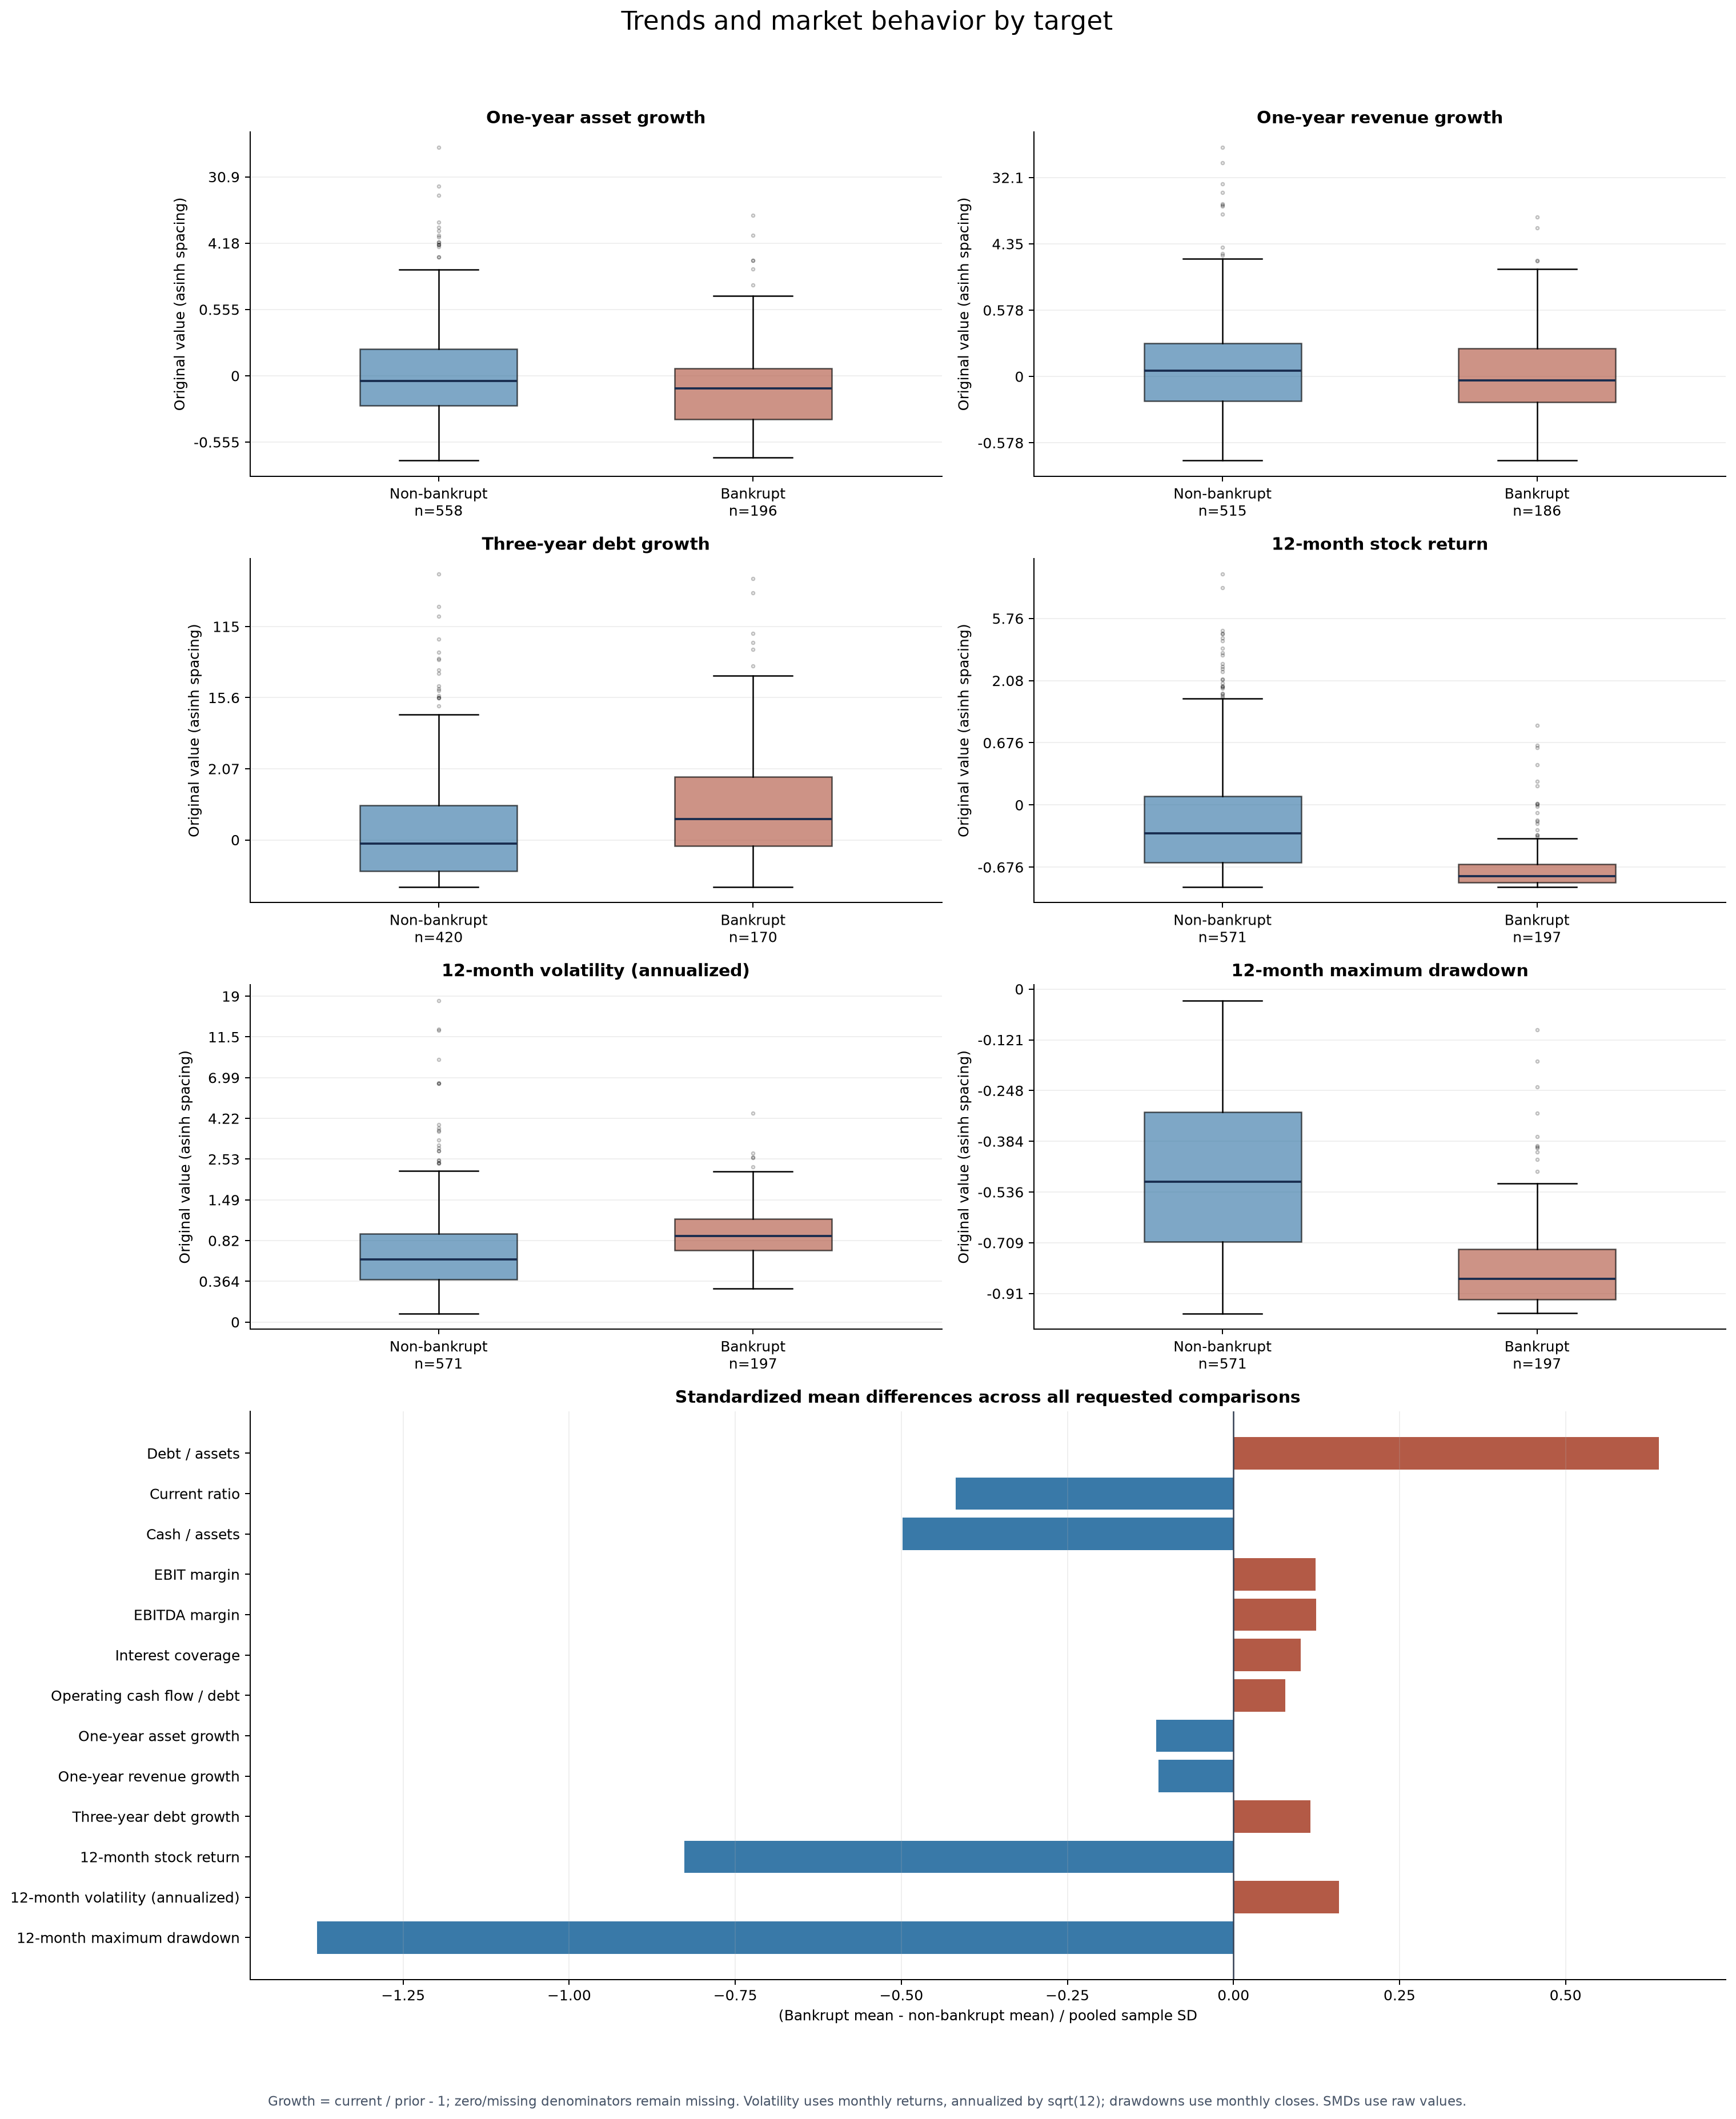

In [4]:
# Compare requested trend/market features and all 13 standardized mean differences.
# SMD uses raw observed values, not asinh display coordinates; no p-values are inferred.
comparison_summary = []
for column, label in comparison_features.items():
    controls = finite_values(column, 0); bankrupt = finite_values(column, 1)
    pooled_sd = np.sqrt((np.var(controls, ddof=1) + np.var(bankrupt, ddof=1)) / 2) if len(controls) > 1 and len(bankrupt) > 1 else np.nan
    smd = (bankrupt.mean() - controls.mean()) / pooled_sd if np.isfinite(pooled_sd) and pooled_sd > 0 else np.nan
    comparison_summary.append({"feature": column, "label": label, "nonbankrupt_n": len(controls), "bankrupt_n": len(bankrupt),
                               "nonbankrupt_median": np.median(controls) if len(controls) else np.nan,
                               "bankrupt_median": np.median(bankrupt) if len(bankrupt) else np.nan,
                               "standardized_mean_difference": smd})
comparison_summary = pd.DataFrame(comparison_summary)
fig = plt.figure(figsize=(17, 21))
grid = fig.add_gridspec(4, 2, height_ratios=[1, 1, 1, 1.65])
for i, (column, label) in enumerate(trend_market_features.items()):
    ax = fig.add_subplot(grid[i // 2, i % 2])
    grouped_boxplot(ax, column, label, transformed=True)
ax = fig.add_subplot(grid[3, :])
smd_table = comparison_summary.iloc[::-1]
y = np.arange(len(smd_table))
smd = smd_table.standardized_mean_difference.to_numpy()
ax.barh(y, smd, color=[COLORS[1] if value >= 0 else COLORS[0] for value in smd])
ax.set_yticks(y, smd_table.label)
ax.axvline(0, color="#344054", linewidth=1)
ax.set(title="Standardized mean differences across all requested comparisons", xlabel="(Bankrupt mean - non-bankrupt mean) / pooled sample SD")
ax.grid(axis="x", alpha=.2)
fig.suptitle("Trends and market behavior by target", fontsize=18)
fig.tight_layout(rect=[0, .04, 1, .96])
save_figure(fig, "trend_comparison_bankrupt_controls.png",
            "Growth = current / prior - 1; zero/missing denominators remain missing. Volatility uses monthly returns, annualized by sqrt(12); drawdowns use monthly closes. SMDs use raw values.")


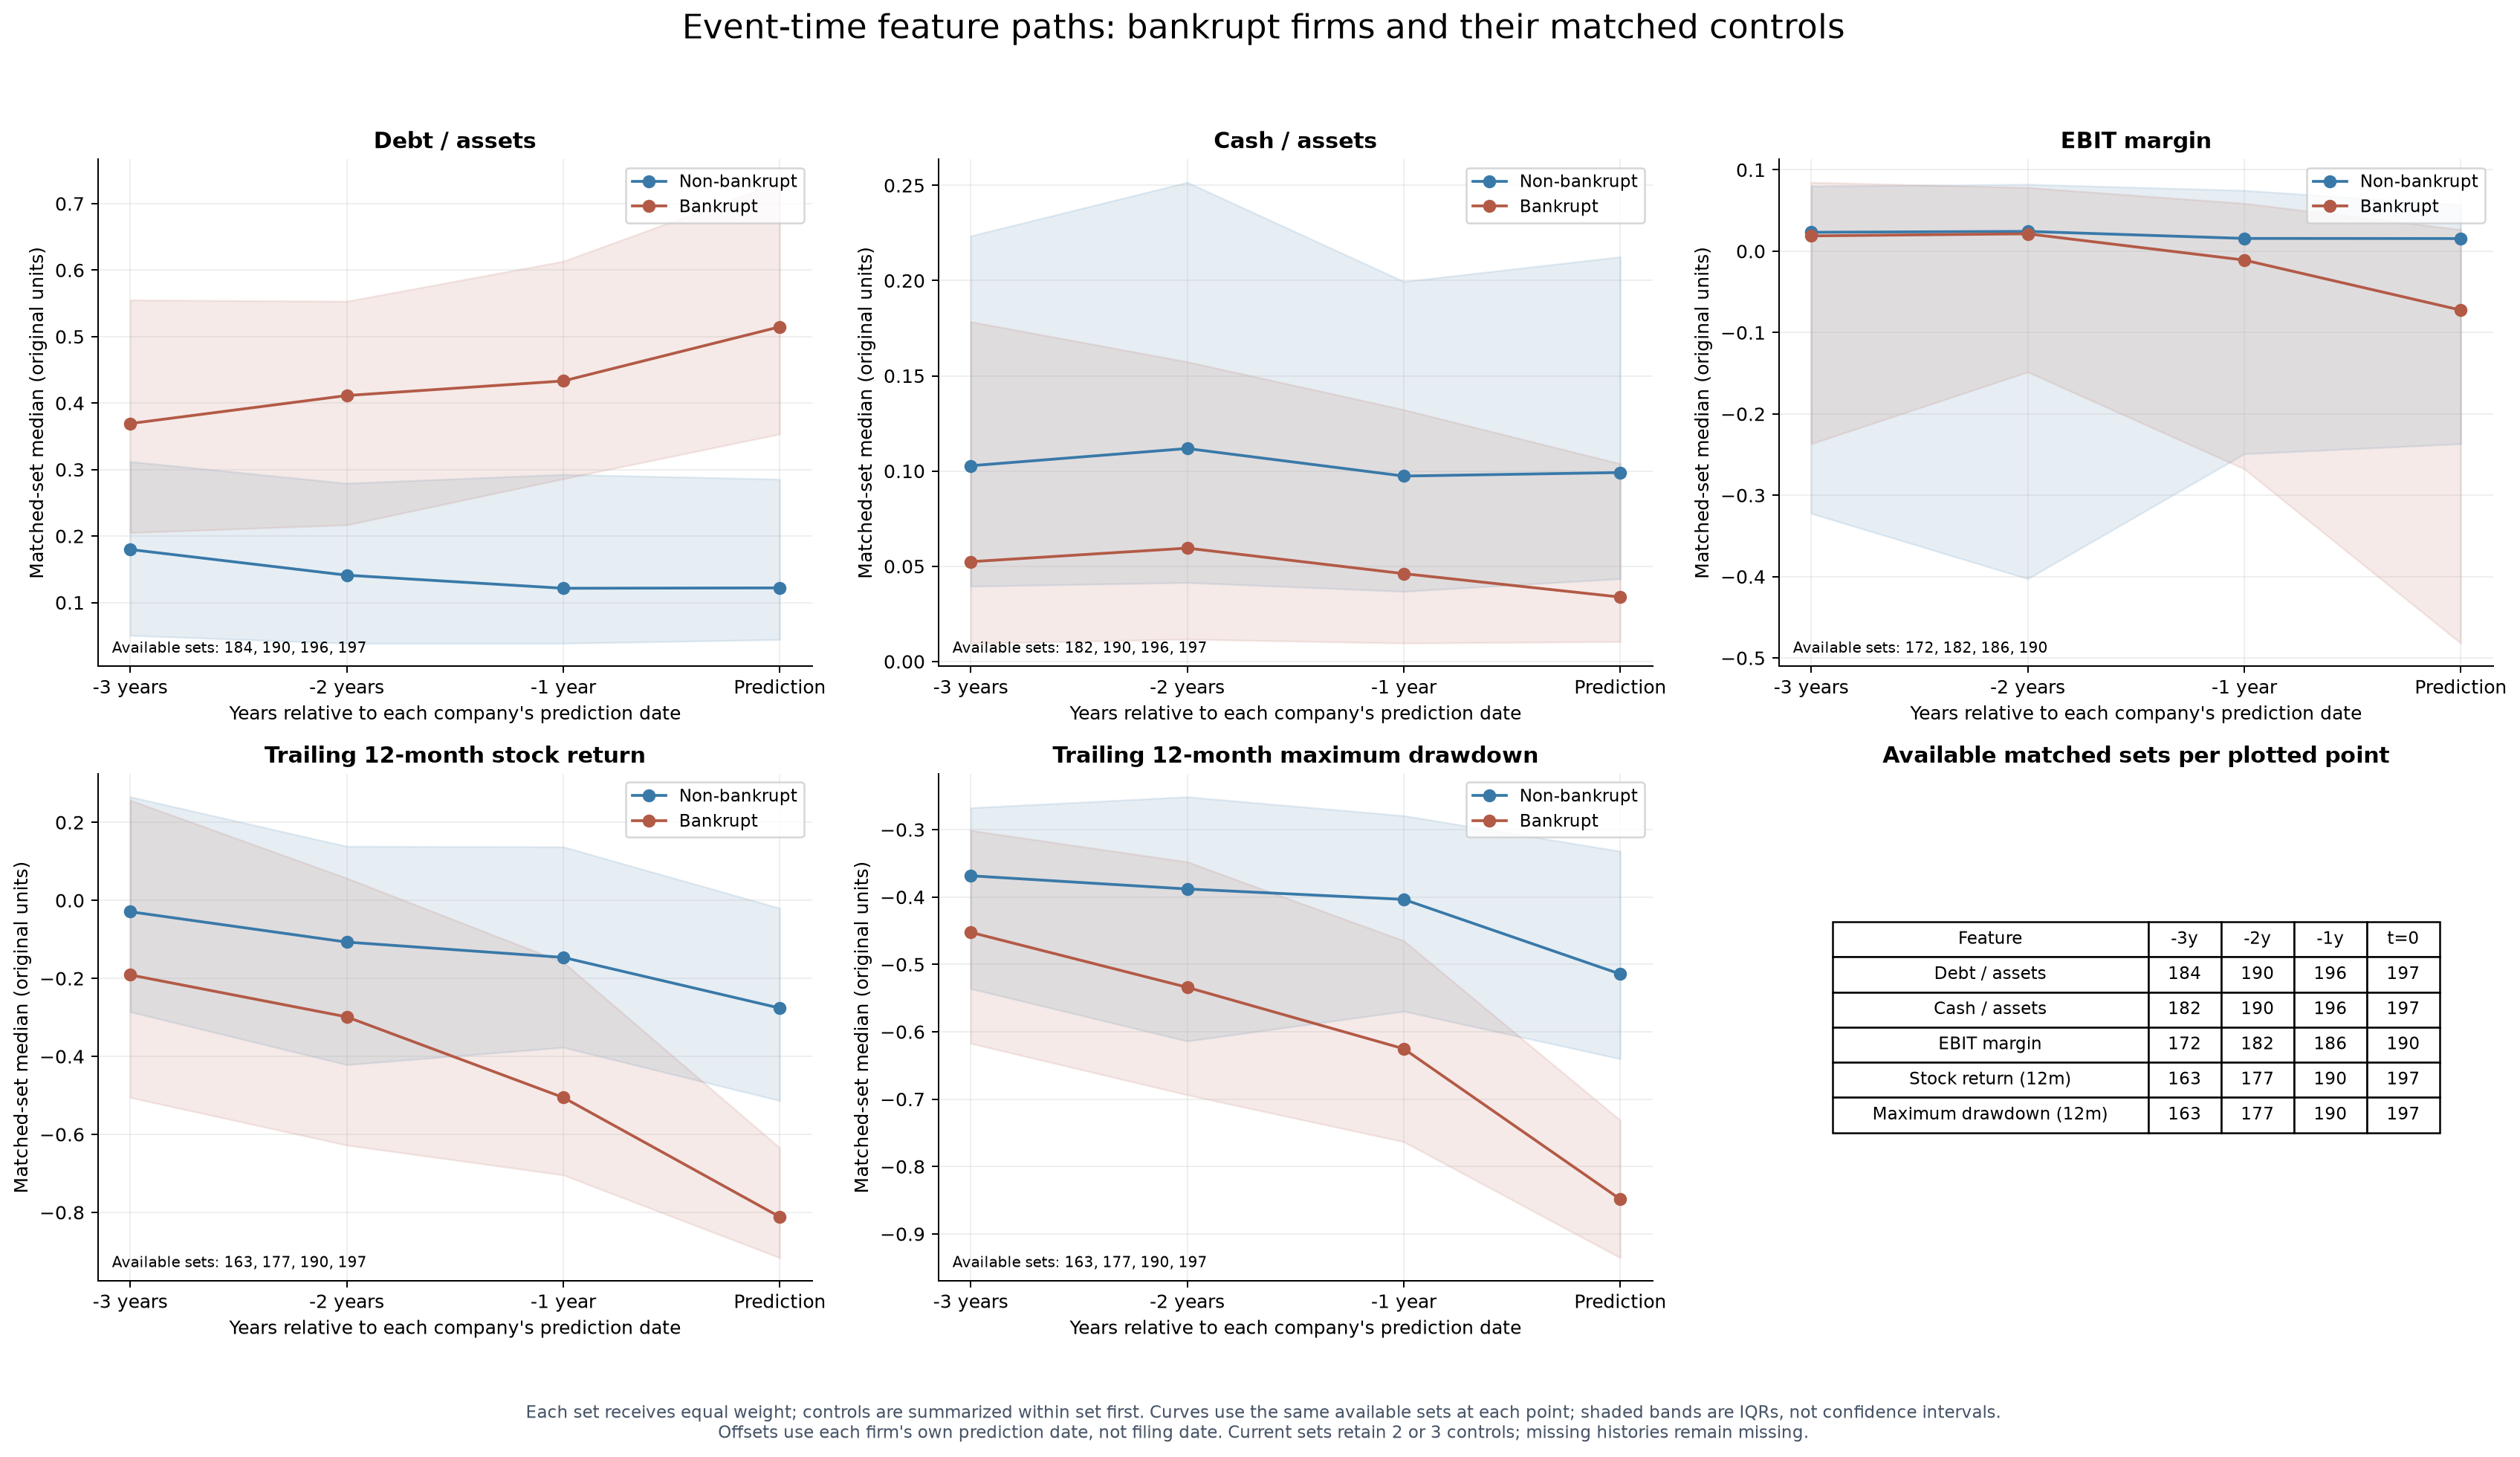

In [5]:
# Reconstruct five event-time paths from company-specific audited history.
history_fields = ["total_assets", "total_debt", "cash_short_term_investments", "ebit", "revenue", "adjusted_price"]
source_path = PROCESSED / "clean_company_long.csv"
input_hashes[source_path] = file_hash(source_path)
company_ids = set(model.company_id)
chunks = []
for chunk in pd.read_csv(source_path, usecols=["company_id", "date", "field", "value"], chunksize=250_000,
                         dtype={"company_id": "string"}):
    selected = chunk.loc[chunk.company_id.isin(company_ids) & chunk.field.isin(history_fields)]
    if len(selected): chunks.append(selected)
history = pd.concat(chunks, ignore_index=True)
history["date"] = pd.to_datetime(history.date, errors="raise").astype("datetime64[ns]")
if history.duplicated(["company_id", "date", "field"]).any():
    raise ValueError("Duplicate historical source records")
lookup = history.set_index(["company_id", "date", "field"]).value
price_histories = {}
for company, group in history.loc[history.field.eq("adjusted_price") & history.value.gt(0)].groupby("company_id", sort=False):
    group = group.sort_values("date")
    price_histories[company] = (group.date.to_numpy(dtype="datetime64[ns]"), group.value.to_numpy(dtype=float))

def historical_values(field, dates, cutoff):
    index = pd.MultiIndex.from_arrays([model.company_id, dates, np.repeat(field, len(model))], names=["company_id", "date", "field"])
    values = lookup.reindex(index).to_numpy(dtype=float)
    valid = dates.notna() & dates.le(cutoff)
    return pd.Series(np.where(valid, values, np.nan), index=model.index)


# Mirror notebook 11's calendar-return endpoints and consecutive monthly DD window.
def trailing_market_path(dates, prices, cutoff, max_age_days=45):
    cutoff = pd.Timestamp(cutoff)
    current_cutoff = cutoff.to_datetime64()
    baseline_cutoff = (cutoff - pd.DateOffset(months=12)).to_datetime64()
    result = {"return_12m": np.nan, "maximum_drawdown_12m": np.nan}
    audit = {"current_date": pd.NaT, "baseline_date": pd.NaT, "window_start_date": pd.NaT,
             "window_end_date": pd.NaT, "n_prices": 0, "baseline_cutoff_date": pd.Timestamp(baseline_cutoff)}
    stop = np.searchsorted(dates, current_cutoff, side="right")
    if not stop or dates[stop-1] < current_cutoff - np.timedelta64(max_age_days, "D"): return result, audit
    past_dates = dates[:stop]
    months = past_dates.astype("datetime64[M]").astype(np.int64)
    positions = np.flatnonzero(np.r_[months[:-1] != months[1:], True])[-13:]
    if len(positions) != 13 or not np.diff(months[positions]).tolist() == [1] * 12: return result, audit
    window_dates = dates[positions]; window_prices = prices[positions]
    result["maximum_drawdown_12m"] = float(np.min(window_prices / np.maximum.accumulate(window_prices) - 1))
    audit.update(current_date=pd.Timestamp(dates[stop-1]), window_start_date=pd.Timestamp(window_dates[0]),
                 window_end_date=pd.Timestamp(window_dates[-1]), n_prices=13)
    baseline_position = np.searchsorted(dates, baseline_cutoff, side="right") - 1
    if baseline_position >= 0 and dates[baseline_position] >= baseline_cutoff - np.timedelta64(max_age_days, "D"):
        result["return_12m"] = float(prices[stop-1] / prices[baseline_position] - 1)
        audit["baseline_date"] = pd.Timestamp(dates[baseline_position])
    return result, audit

path_labels = {"debt_to_assets": "Debt / assets", "cash_to_assets": "Cash / assets", "ebit_margin": "EBIT margin",
               "return_12m": "Trailing 12-month stock return", "maximum_drawdown_12m": "Trailing 12-month maximum drawdown"}
path_values = {}
path_audits = []
for lag in [3, 2, 1, 0]:
    cutoff = prediction_dates - pd.DateOffset(years=lag)
    date_column = "metadata_financial_reference_date" if lag == 0 else f"metadata_trend_financial_reference_date_{lag}y"
    financial_dates = pd.to_datetime(model[date_column], errors="raise").astype("datetime64[ns]")
    observed = financial_dates.notna()
    fields = {field: historical_values(field, financial_dates, cutoff - pd.Timedelta(days=FINANCIAL_REPORTING_LAG_DAYS))
              for field in history_fields if field != "adjusted_price"}
    snapshot = {"debt_to_assets": safe_divide(fields["total_debt"], fields["total_assets"]),
                "cash_to_assets": safe_divide(fields["cash_short_term_investments"], fields["total_assets"]),
                "ebit_margin": safe_divide(fields["ebit"], fields["revenue"])}
    market_records = []
    for index in model.index:
        dates, prices = price_histories.get(model.loc[index, "company_id"],
                                            (np.array([], dtype="datetime64[ns]"), np.array([], dtype=float)))
        values, audit = trailing_market_path(dates, prices, cutoff.loc[index], MAX_MARKET_AGE_DAYS)
        market_records.append(values)
        path_audits.append({"event_index": index, "year_lag": lag, "cutoff_date": cutoff.loc[index],
                            "financial_reference_date": financial_dates.loc[index], **audit})
    market_frame = pd.DataFrame(market_records, index=model.index)
    path_values[lag] = pd.DataFrame(snapshot, index=model.index).join(market_frame)
path_audits = pd.DataFrame(path_audits)
for column in ["current_date", "baseline_date", "window_start_date", "window_end_date", "financial_reference_date"]:
    dates = pd.to_datetime(path_audits[column])
    observed = dates.notna()
observed_baseline = path_audits.baseline_date.notna()
for feature in path_labels:
    output_column = "derived_" + feature if feature in ["debt_to_assets", "cash_to_assets", "ebit_margin"] else "market_" + feature

# One control median per bankrupt matched set avoids overweighting larger sets.
# At each point use exactly the same available matched sets for both group medians.
path_summary = []
for lag, snapshots in path_values.items():
    for feature in path_labels:
        pairs_at_point = retained_pair_indices.copy()
        pairs_at_point["bankrupt_value"] = pairs_at_point.bank_index.map(snapshots[feature])
        pairs_at_point["control_value"] = pairs_at_point.control_index.map(snapshots[feature])
        available = pairs_at_point.dropna(subset=["bankrupt_value", "control_value"])
        sets = available.groupby("bank_index").agg(bankrupt_value=("bankrupt_value", "first"),
            control_value=("control_value", "median"), available_controls=("control_index", "nunique"))
        record = {"feature": feature, "relative_year": -lag, "matched_sets": len(sets),
                  "control_observations": int(sets.available_controls.sum())}
        for group, column in [(1, "bankrupt_value"), (0, "control_value")]:
            values = sets[column]
            record[f"median_{group}"] = values.median()
            record[f"q25_{group}"] = values.quantile(.25)
            record[f"q75_{group}"] = values.quantile(.75)
        path_summary.append(record)
path_summary = pd.DataFrame(path_summary).sort_values(["feature", "relative_year"])
fig, axes = plt.subplots(2, 3, figsize=(19, 11))
for ax, (feature, label) in zip(axes.flat, path_labels.items()):
    table = path_summary.loc[path_summary.feature.eq(feature)]
    for group in [0, 1]:
        ax.plot(table.relative_year, table[f"median_{group}"], marker="o", color=COLORS[group], label=GROUP_NAMES[group])
        ax.fill_between(table.relative_year.to_numpy(), table[f"q25_{group}"].to_numpy(), table[f"q75_{group}"].to_numpy(), color=COLORS[group], alpha=.12)
    ax.set_title(label)
    ax.set_xticks([-3, -2, -1, 0], ["-3 years", "-2 years", "-1 year", "Prediction"])
    ax.set_xlabel("Years relative to each company's prediction date")
    ax.set_ylabel("Matched-set median (original units)")
    ax.grid(alpha=.2); ax.legend(fontsize=9, loc="upper right")
    ax.text(.02, .02, "Available sets: " + ", ".join(str(n) for n in table.matched_sets), transform=ax.transAxes, fontsize=8, va="bottom")
axes.flat[-1].axis("off")
coverage = path_summary.pivot(index="feature", columns="relative_year", values="matched_sets").reindex(path_labels)
coverage.index = coverage.index.map(path_labels)
coverage.columns = ["-3y", "-2y", "-1y", "Prediction"]
axes.flat[-1].set_title("Available matched sets per plotted point")
coverage_display = coverage.rename(index={"Trailing 12-month stock return": "Stock return (12m)", "Trailing 12-month maximum drawdown": "Maximum drawdown (12m)"})
coverage_table = axes.flat[-1].table(cellText=[[label] + row.tolist() for label, row in coverage_display.iterrows()], colLabels=["Feature", "-3y", "-2y", "-1y", "t=0"], colWidths=[.52, .12, .12, .12, .12], loc="center", cellLoc="center")
coverage_table.auto_set_font_size(False); coverage_table.set_fontsize(9); coverage_table.scale(.85, 1.6)
fig.suptitle("Event-time feature paths: bankrupt firms and their matched controls", fontsize=18)
fig.tight_layout(rect=[0, .065, 1, .95])
save_figure(fig, "event_time_feature_paths.png",
            "Each set receives equal weight; controls are summarized within set first. Curves use the same available sets at each point; shaded bands are IQRs, not confidence intervals.\nOffsets use each firm's own prediction date, not filing date. Current sets retain 2 or 3 controls; missing histories remain missing.")


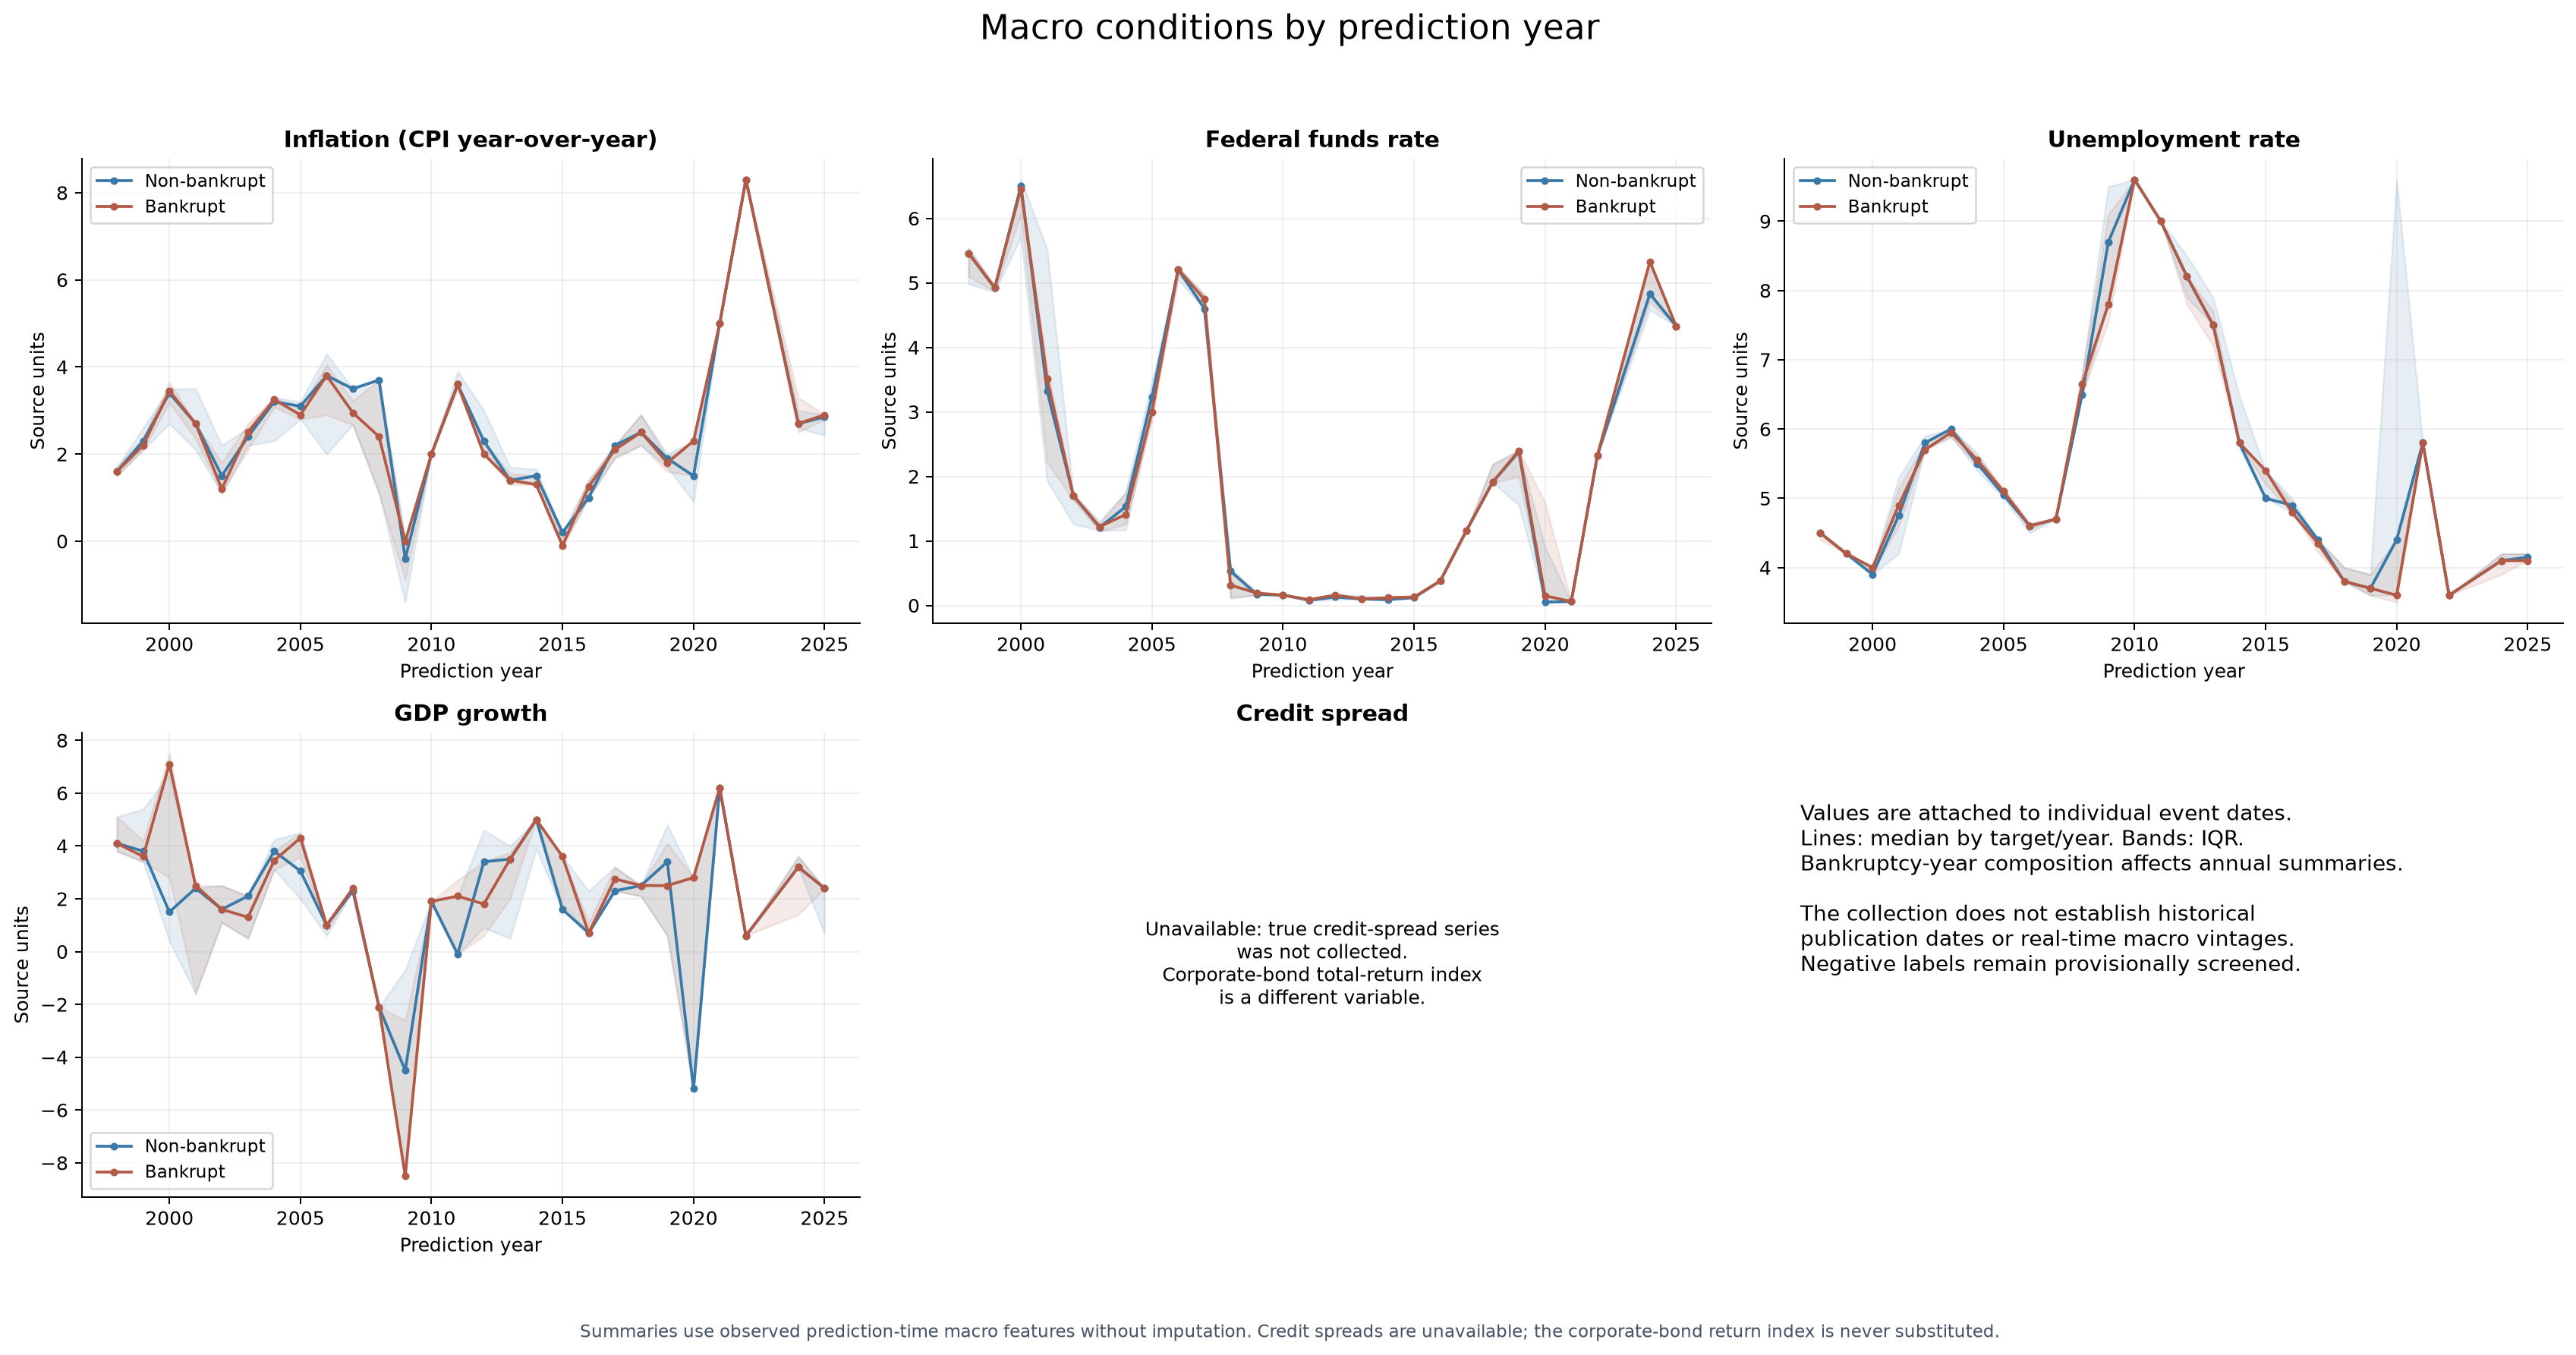

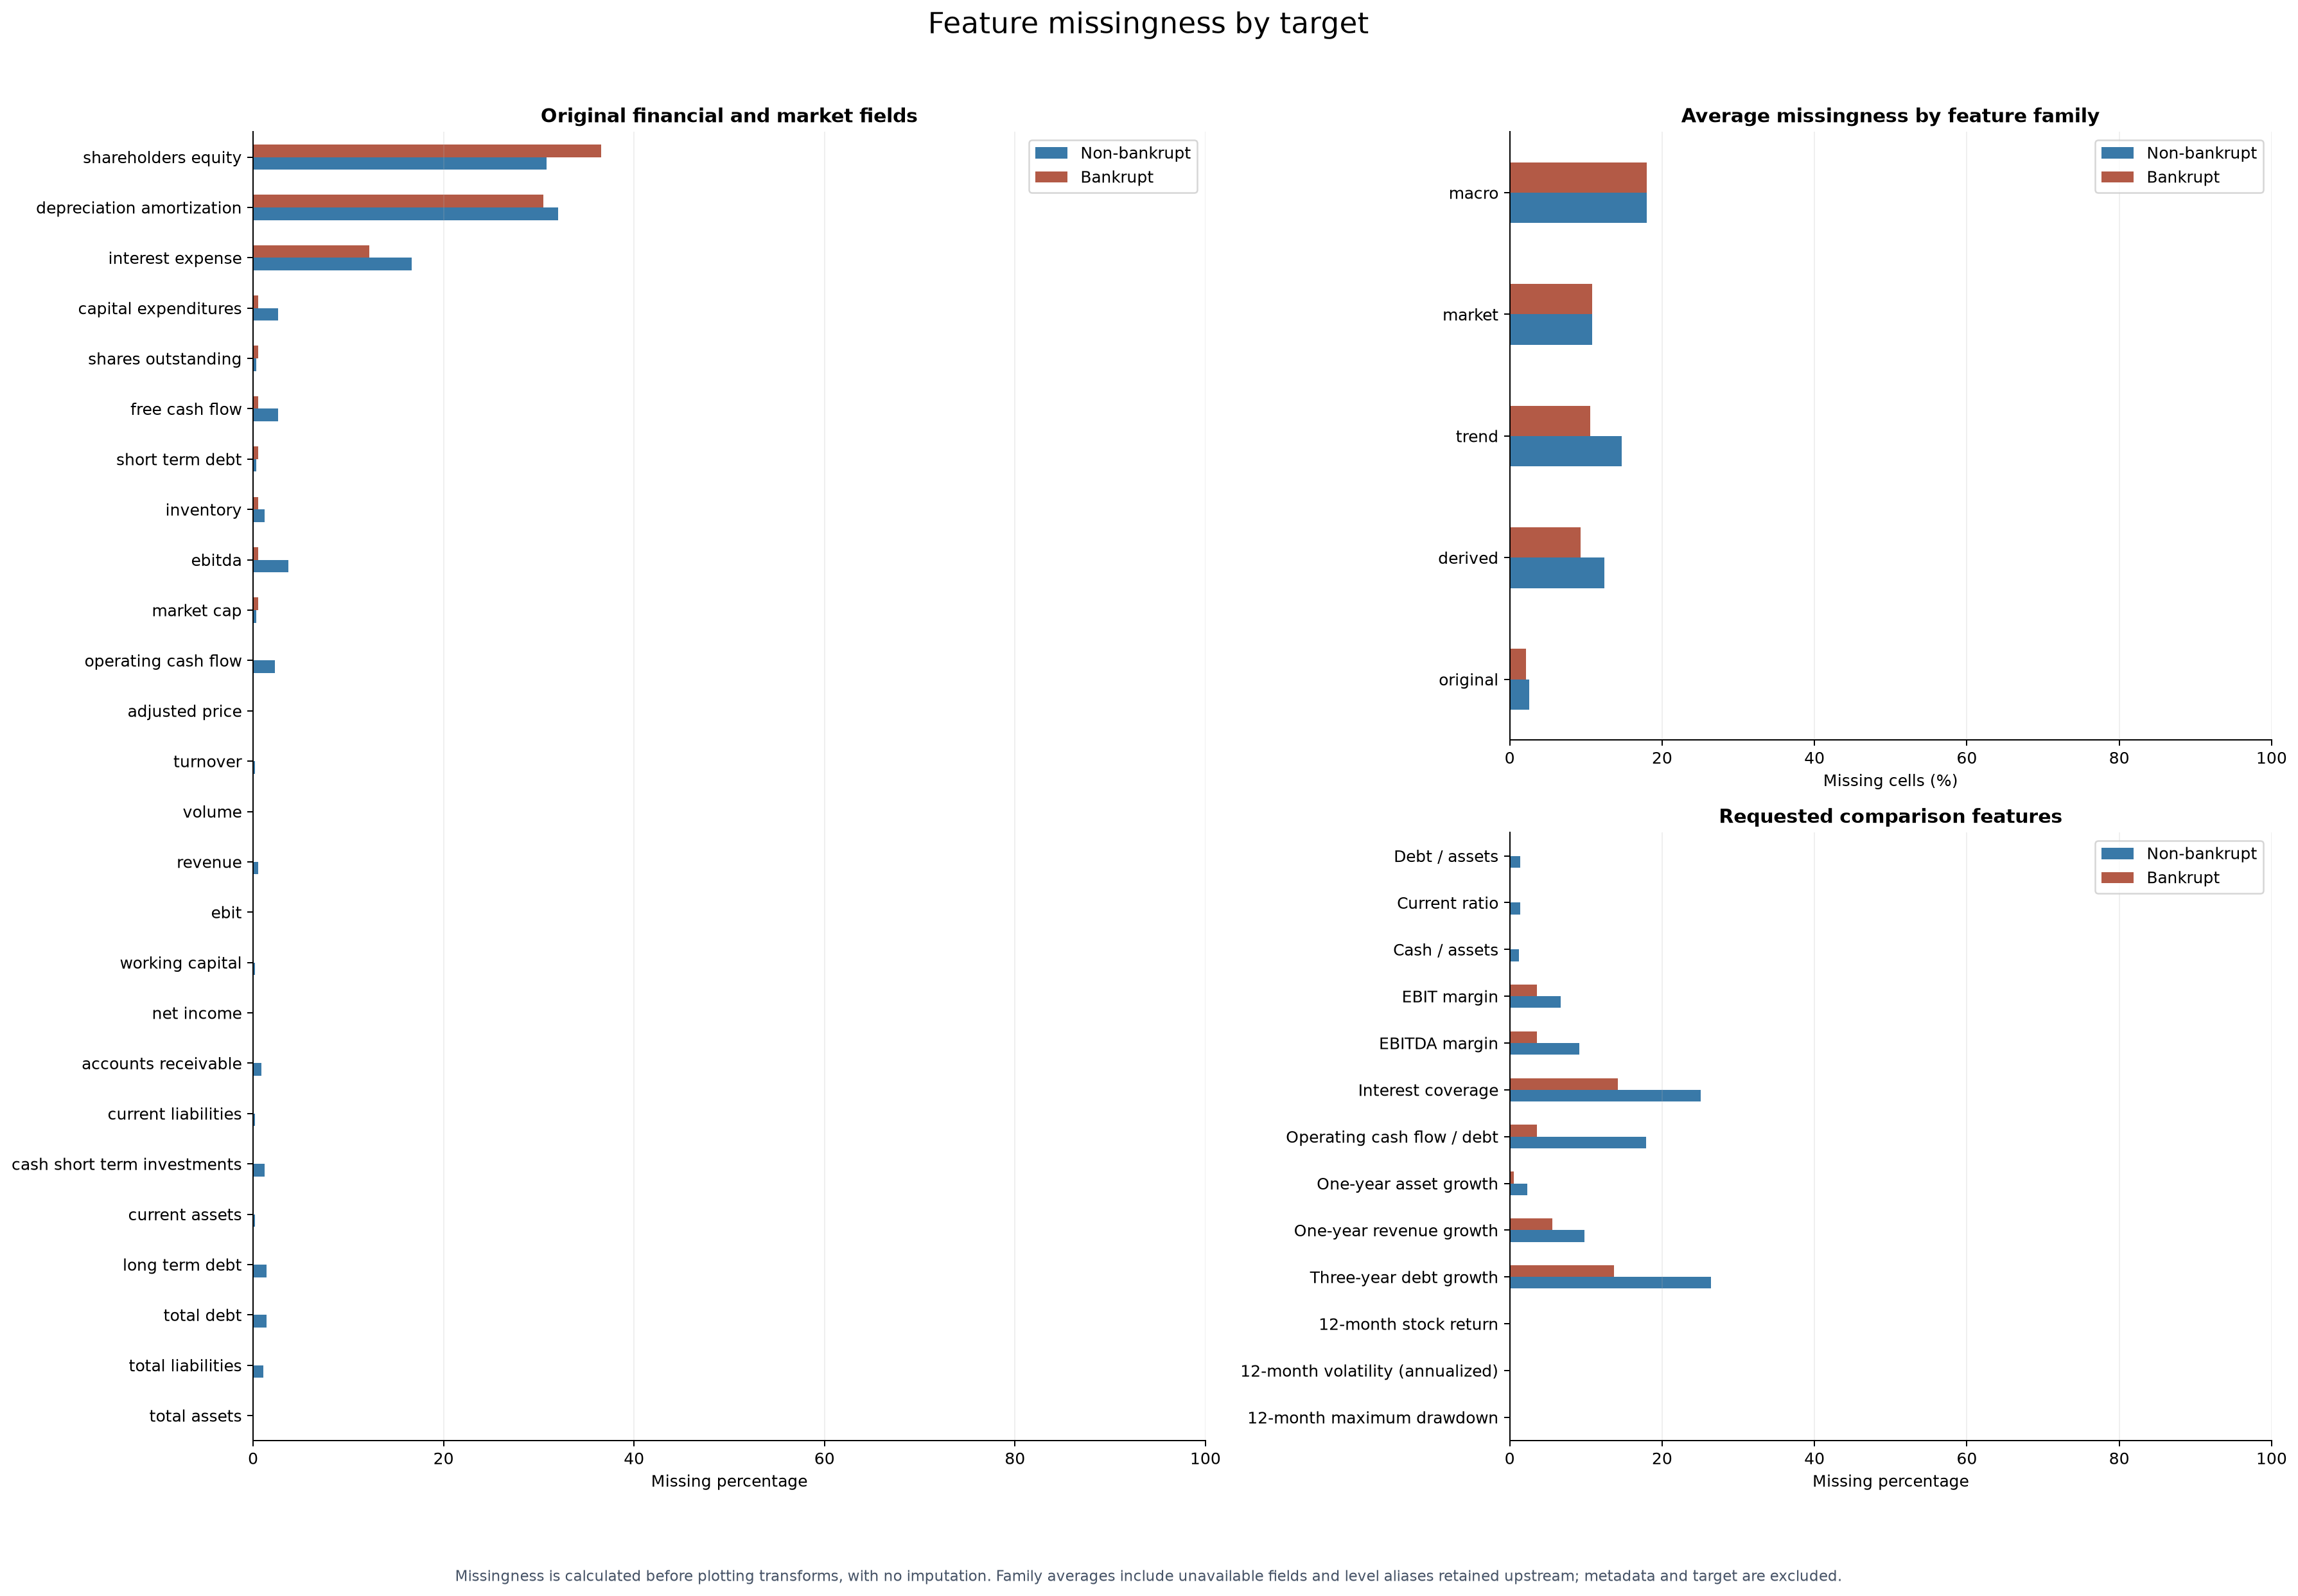

In [6]:
# Macro conditions summarize each event's own prediction-date values by event year.
# Different dates within a year can differ; median/IQR summaries do not replace values.
macro_examples = {
    "macro_inflation_level": "Inflation (CPI year-over-year)", "macro_federal_funds_rate": "Federal funds rate",
    "macro_unemployment_rate": "Unemployment rate", "macro_gdp_growth": "GDP growth",
    "macro_credit_spread": "Credit spread",
}
fig, axes = plt.subplots(2, 3, figsize=(19, 10))
macro_summaries = []
for ax, (column, label) in zip(axes.flat, macro_examples.items()):
    if column not in model or not model[column].notna().any():
        ax.axis("off")
        ax.set_title(label)
        ax.text(.5, .5, "Unavailable: true credit-spread series\nwas not collected.\nCorporate-bond total-return index\nis a different variable.", ha="center", va="center", transform=ax.transAxes)
        continue
    for group in [0, 1]:
        subset = model.loc[model.target.eq(group), ["prediction_year", column]]
        grouped = subset.groupby("prediction_year")[column]
        table = grouped.agg(observed="count", median="median")
        table["q25"] = grouped.quantile(.25); table["q75"] = grouped.quantile(.75)
        macro_summaries.append(table.reset_index().assign(feature=column, target=group))
        ax.plot(table.index, table["median"], marker=".", color=COLORS[group], label=GROUP_NAMES[group])
        ax.fill_between(table.index.to_numpy(), table.q25.to_numpy(), table.q75.to_numpy(), color=COLORS[group], alpha=.12)
    ax.set(title=label, xlabel="Prediction year", ylabel="Source units")
    ax.grid(alpha=.2); ax.legend(fontsize=9)
axes.flat[-1].axis("off")
axes.flat[-1].text(.02, .85, "Values are attached to individual event dates.\nLines: median by target/year. Bands: IQR.\nBankruptcy-year composition affects annual summaries.\n\nThe collection does not establish historical\npublication dates or real-time macro vintages.\nNegative labels remain provisionally screened.", va="top", fontsize=11)
fig.suptitle("Macro conditions by prediction year", fontsize=18)
fig.tight_layout(rect=[0, .055, 1, .95])
save_figure(fig, "macro_conditions_by_event_year.png",
            "Summaries use observed prediction-time macro features without imputation. Credit spreads are unavailable; the corporate-bond return index is never substituted.")
macro_summaries = pd.concat(macro_summaries, ignore_index=True)

# Compare missingness for original fields and for each engineered feature family.
original_missing = pd.DataFrame({GROUP_NAMES[target]: model.loc[model.target.eq(target), [f"original_{c}" for c in financial_columns + ["adjusted_price", "market_cap", "shares_outstanding", "volume", "turnover"]]].isna().mean() * 100
                                for target in [0, 1]})
original_missing.index = original_missing.index.str.removeprefix("original_").str.replace("_", " ")
original_missing = original_missing.sort_values("Bankrupt", ascending=True)
family_missing = pd.DataFrame({GROUP_NAMES[target]: {group: model.loc[model.target.eq(target), [c for c in feature_columns if c.startswith(group + "_")]].isna().to_numpy().mean() * 100
                                for group in ["original", "derived", "trend", "market", "macro"]} for target in [0, 1]})
selected_missing = pd.DataFrame({GROUP_NAMES[target]: model.loc[model.target.eq(target), list(comparison_features)].isna().mean() * 100 for target in [0, 1]})
selected_missing.index = selected_missing.index.map(comparison_features)
fig = plt.figure(figsize=(20, 14))
grid = fig.add_gridspec(2, 2, width_ratios=[1.25, 1])
ax = fig.add_subplot(grid[:, 0]); original_missing.plot.barh(ax=ax, color=[COLORS[0], COLORS[1]])
ax.set(title="Original financial and market fields", xlabel="Missing percentage", ylabel="")
ax.set_xlim(0, 100); ax.grid(axis="x", alpha=.2)
ax = fig.add_subplot(grid[0, 1]); family_missing.plot.barh(ax=ax, color=[COLORS[0], COLORS[1]])
ax.set(title="Average missingness by feature family", xlabel="Missing cells (%)", ylabel=""); ax.set_xlim(0, 100); ax.grid(axis="x", alpha=.2)
ax = fig.add_subplot(grid[1, 1]); selected_missing.iloc[::-1].plot.barh(ax=ax, color=[COLORS[0], COLORS[1]])
ax.set(title="Requested comparison features", xlabel="Missing percentage", ylabel=""); ax.set_xlim(0, 100); ax.grid(axis="x", alpha=.2)
fig.suptitle("Feature missingness by target", fontsize=18)
fig.tight_layout(rect=[0, .055, 1, .96])
save_figure(fig, "feature_missingness_by_target.png",
            "Missingness is calculated before plotting transforms, with no imputation. Family averages include unavailable fields and level aliases retained upstream; metadata and target are excluded.")


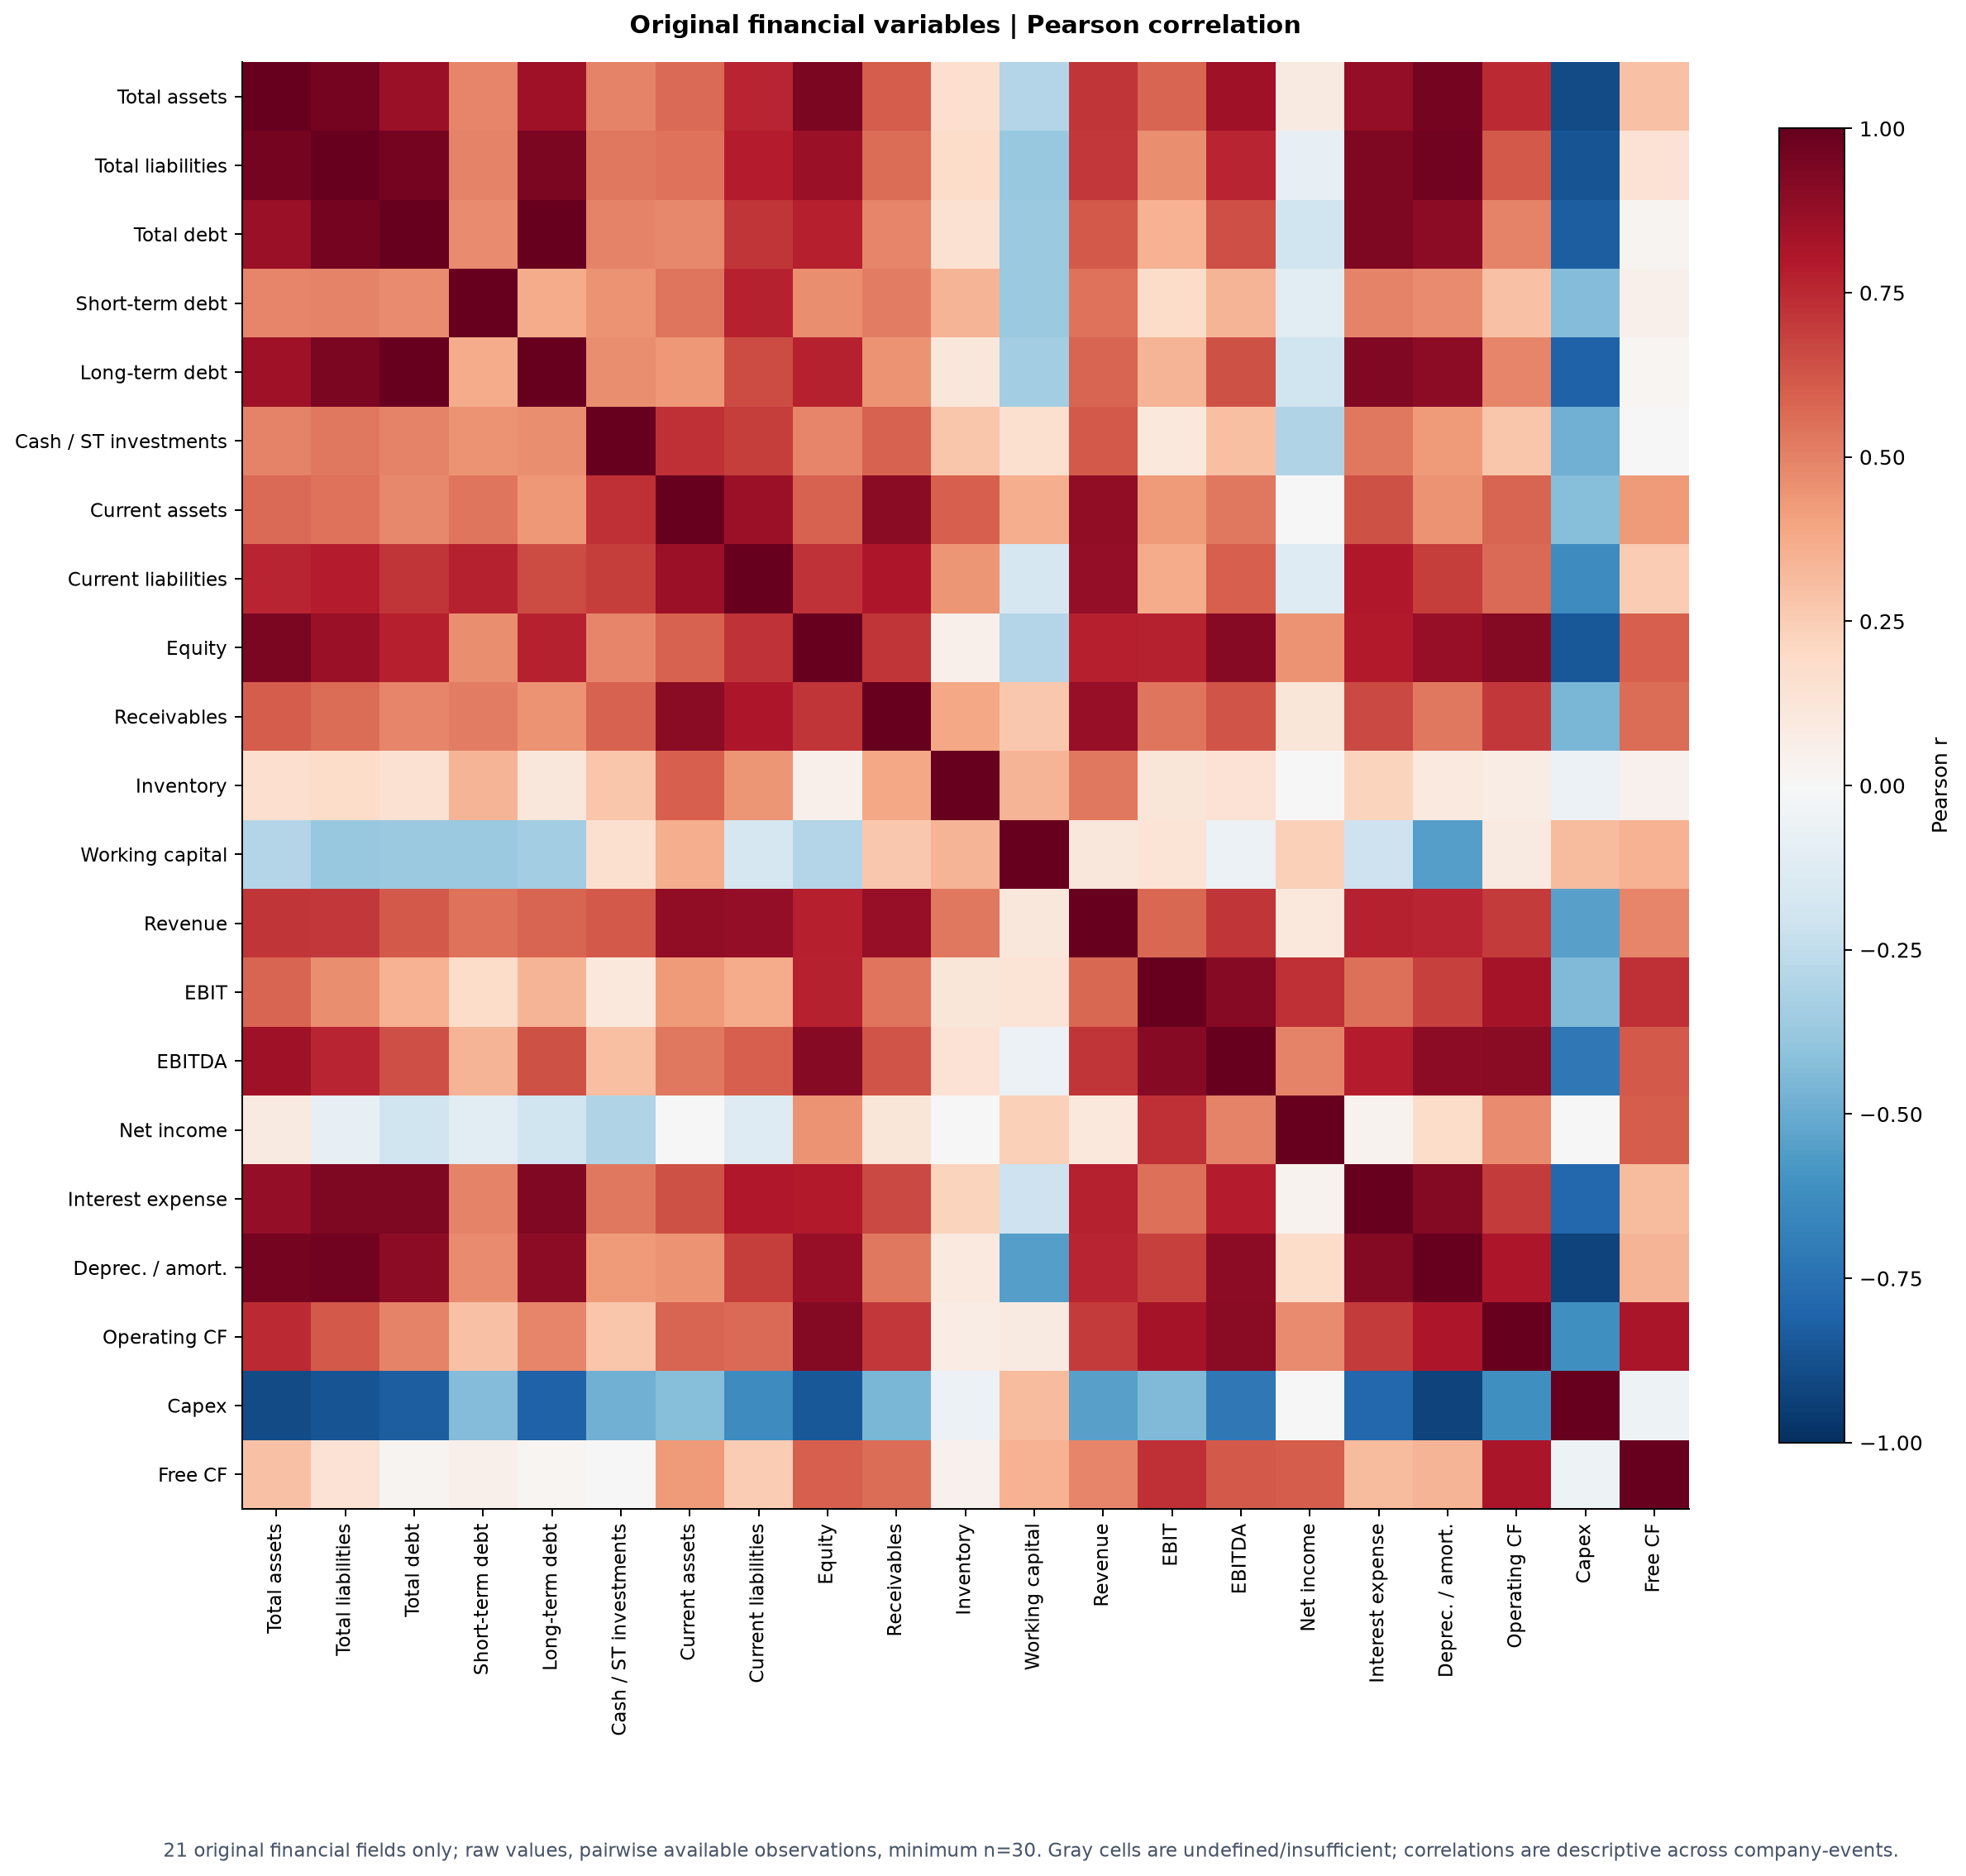

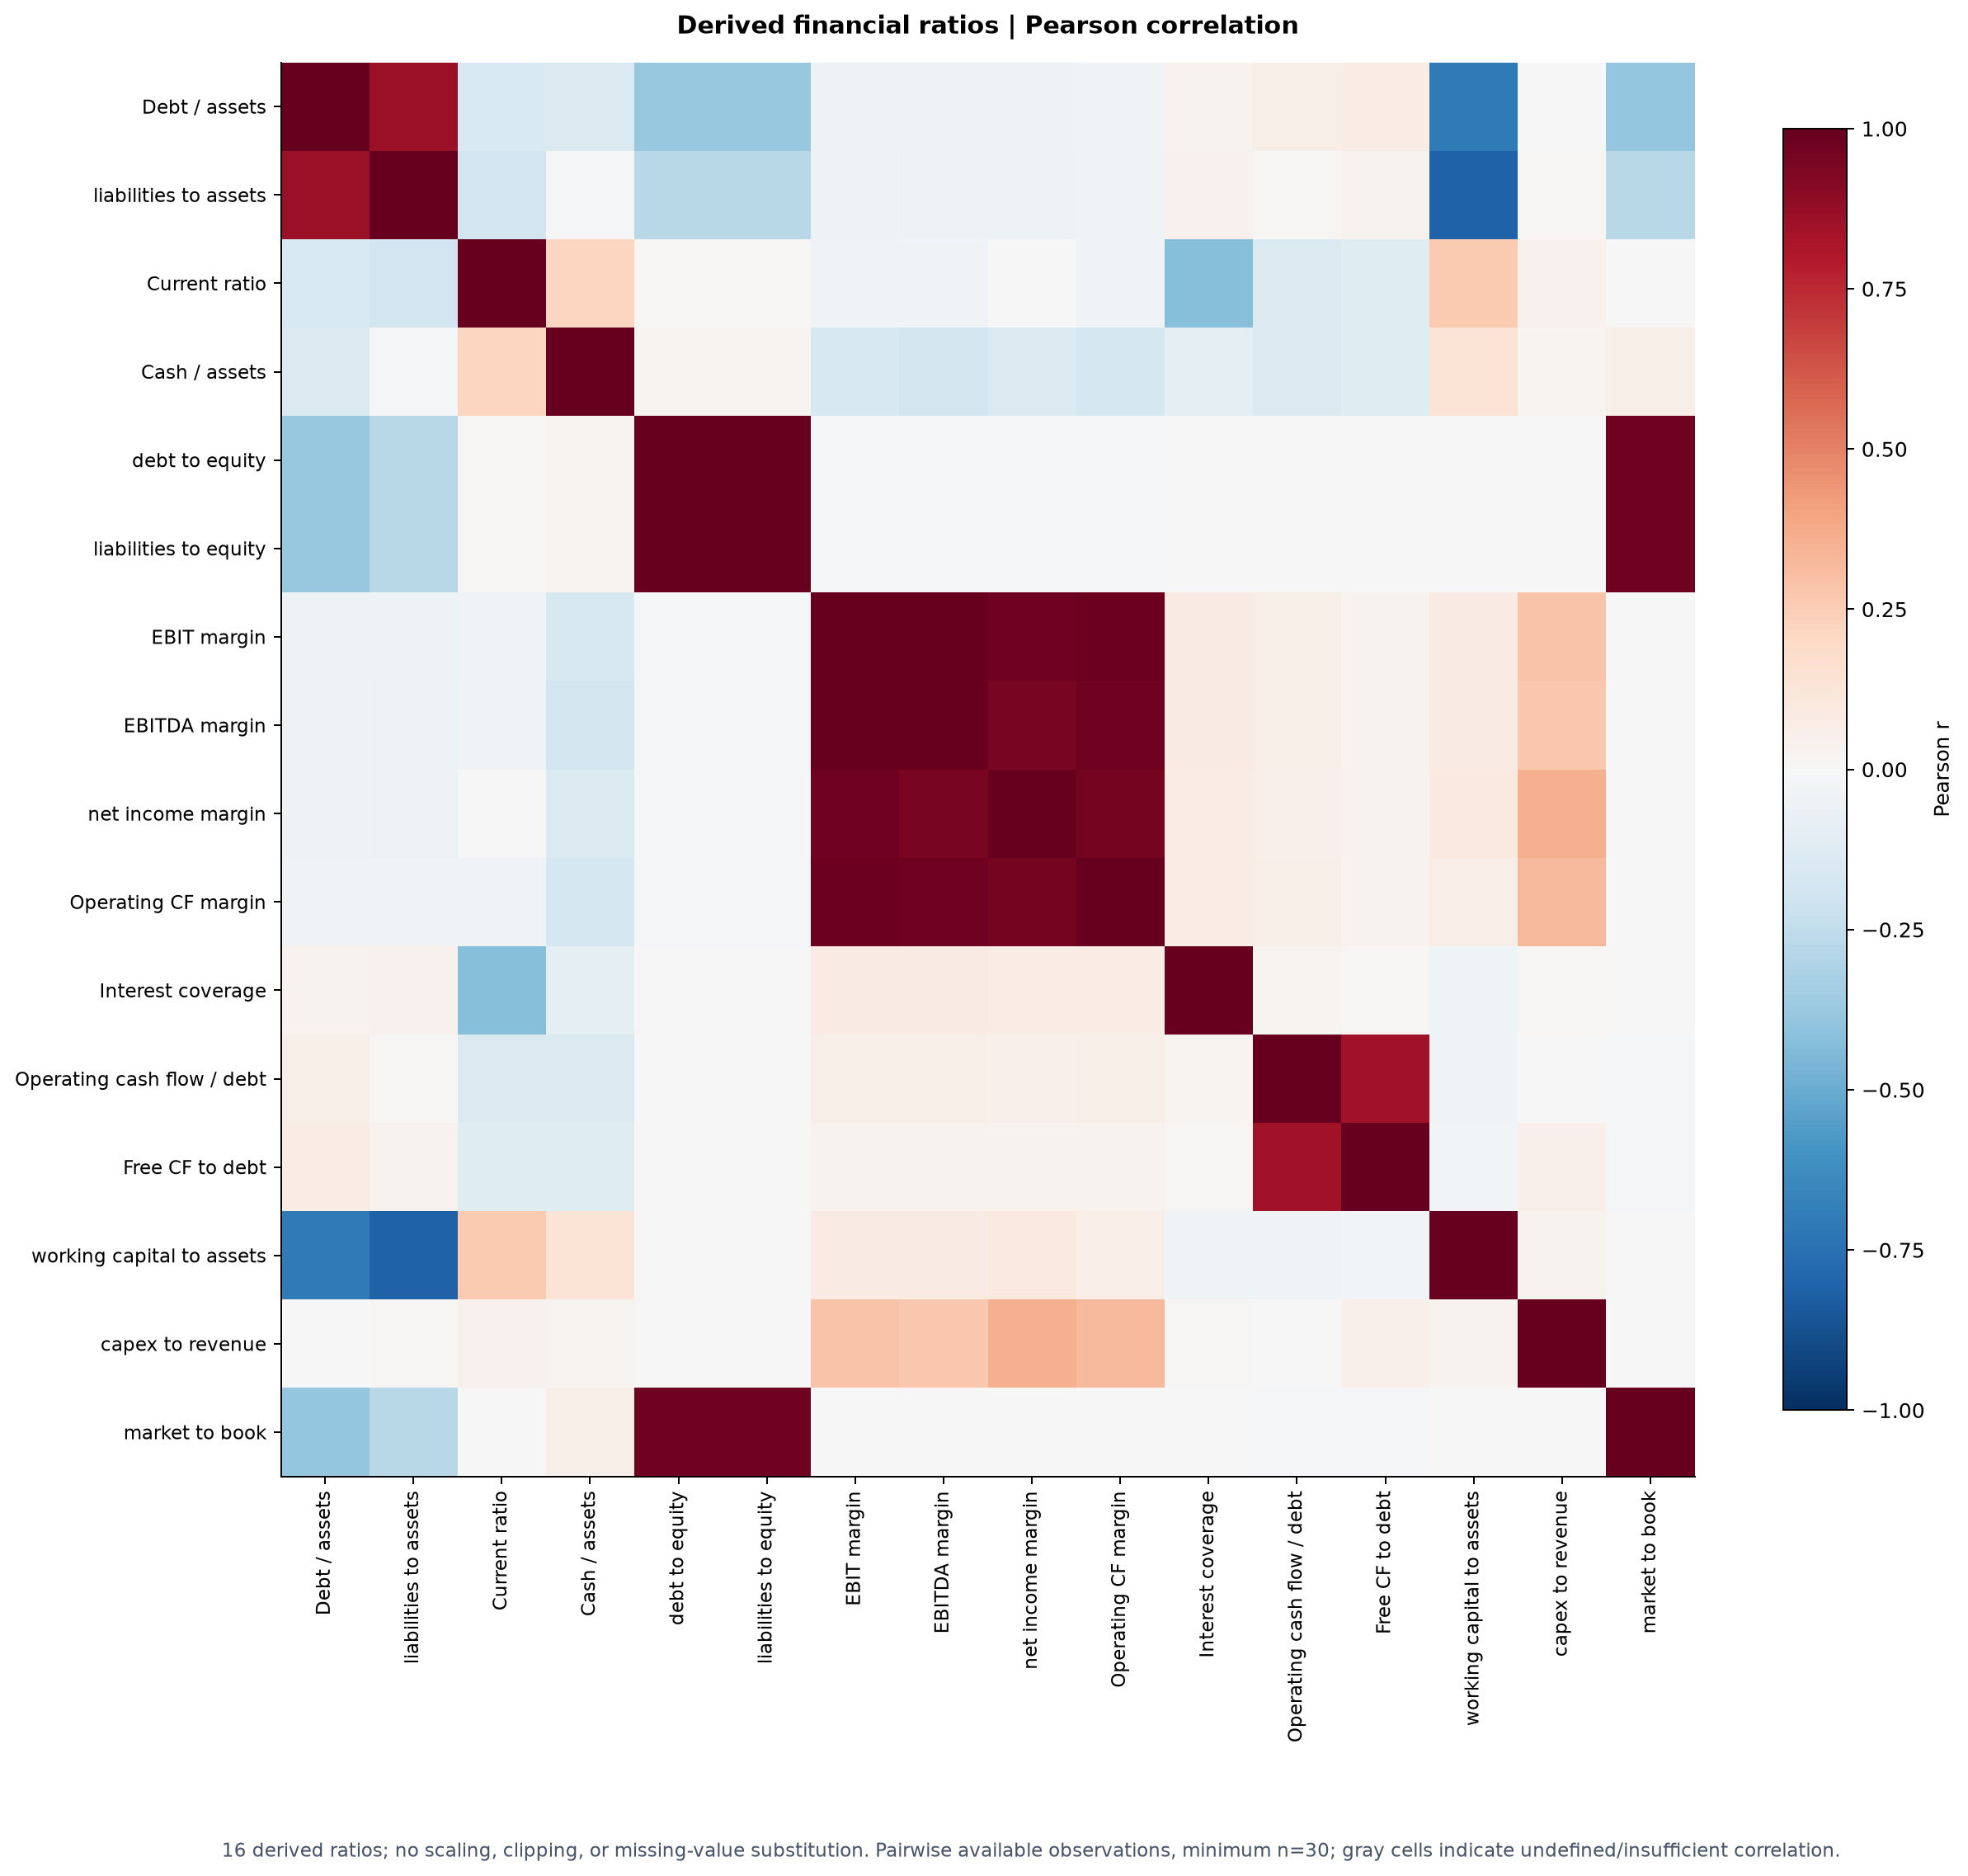

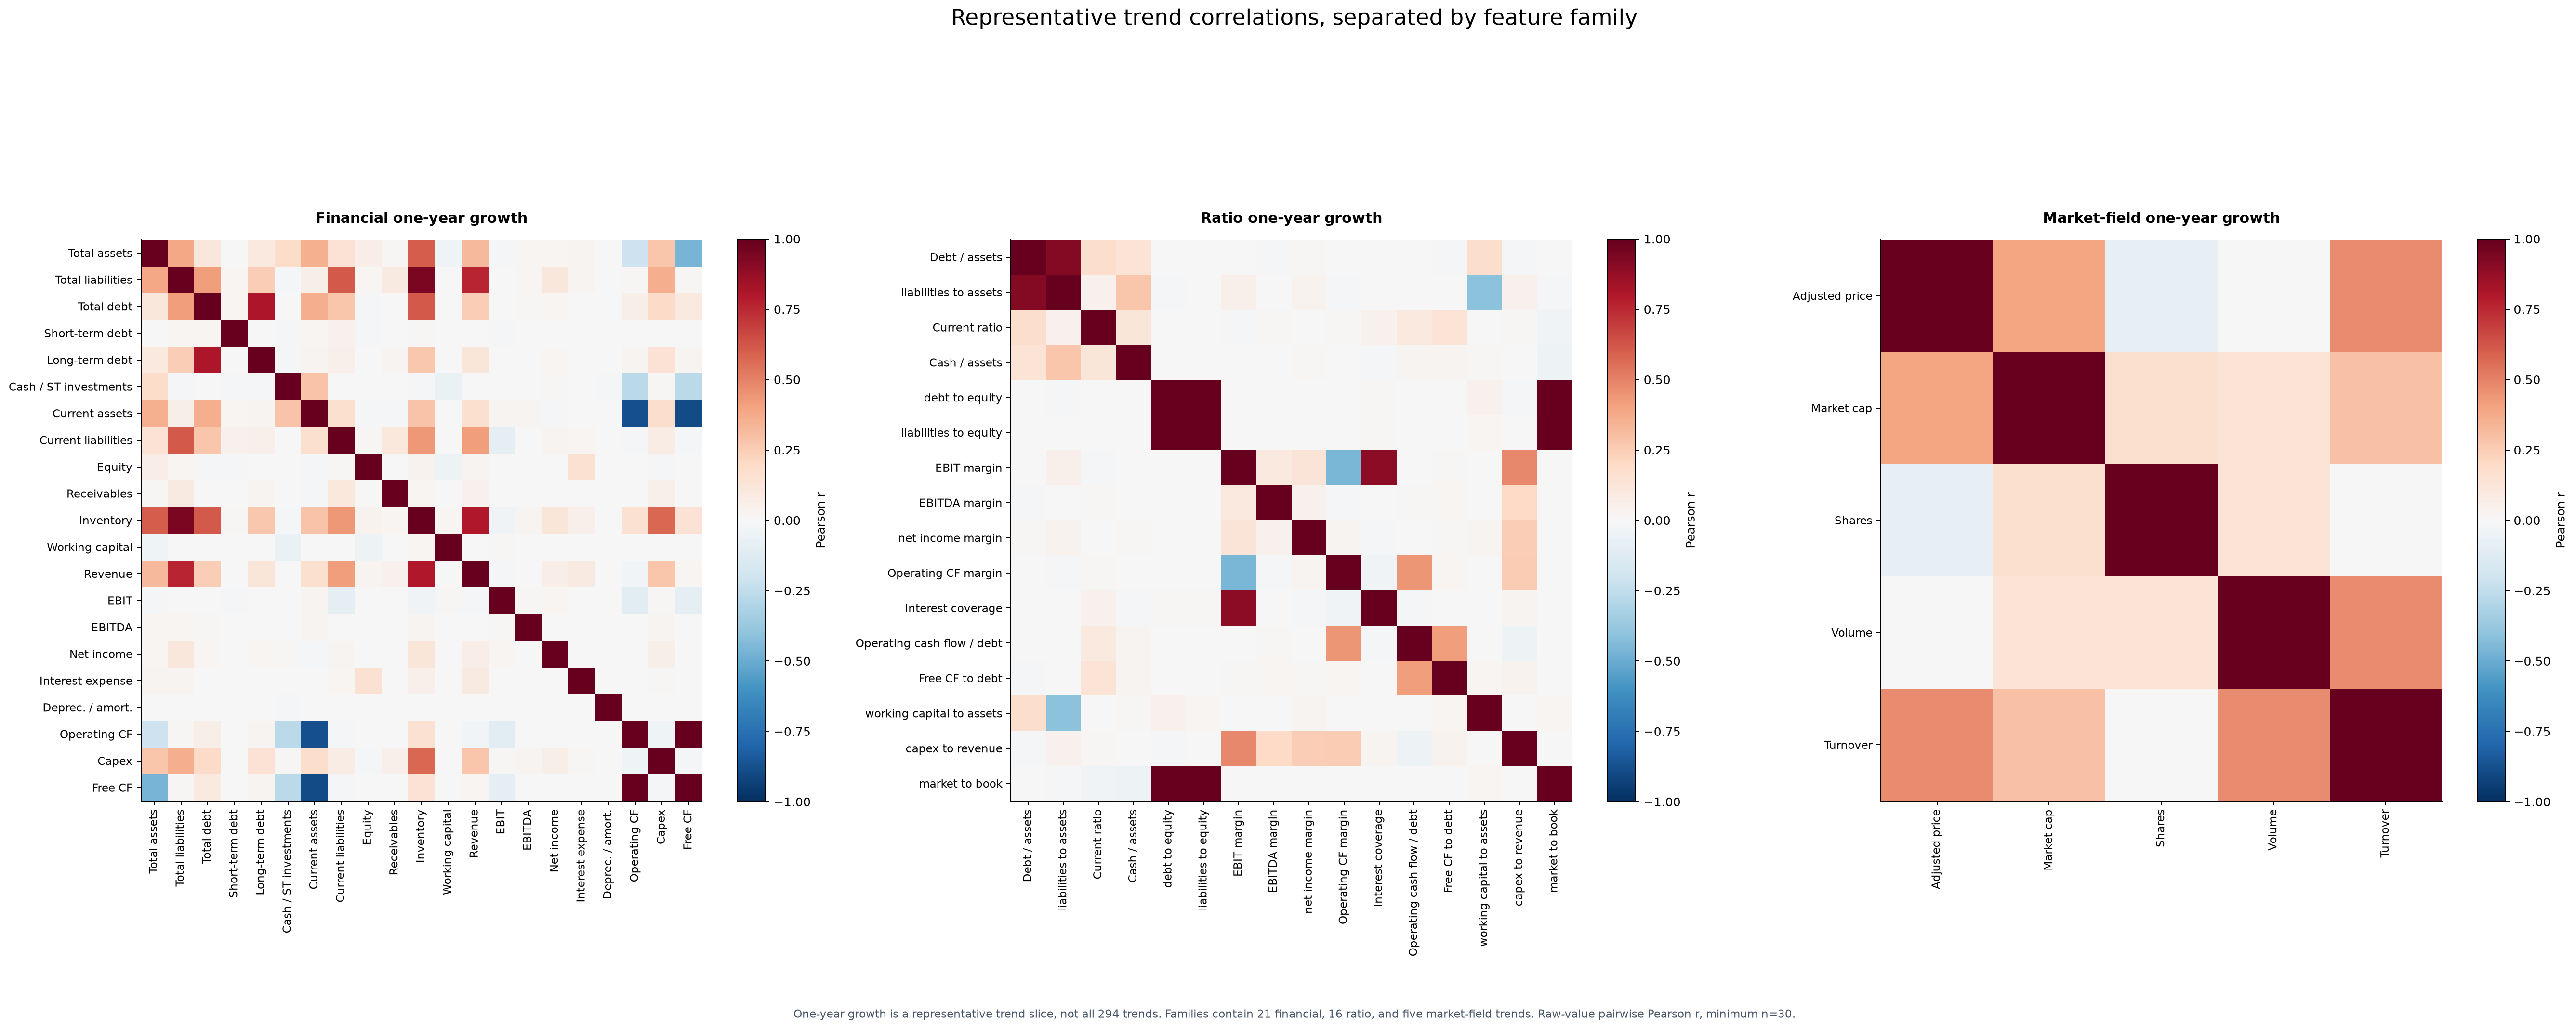

In [7]:
# Separate original financial, derived ratio, and representative trend correlations.
# Pairwise Pearson correlations retain missingness and require at least 30 observations.
short_names = {
    "total_assets": "Total assets", "total_liabilities": "Total liabilities", "total_debt": "Total debt",
    "short_term_debt": "Short-term debt", "long_term_debt": "Long-term debt",
    "cash_short_term_investments": "Cash / ST investments", "current_assets": "Current assets",
    "current_liabilities": "Current liabilities", "shareholders_equity": "Equity", "accounts_receivable": "Receivables",
    "inventory": "Inventory", "working_capital": "Working capital", "revenue": "Revenue", "ebit": "EBIT",
    "ebitda": "EBITDA", "net_income": "Net income", "interest_expense": "Interest expense",
    "depreciation_amortization": "Deprec. / amort.", "operating_cash_flow": "Operating CF",
    "capital_expenditures": "Capex", "free_cash_flow": "Free CF", "adjusted_price": "Adjusted price",
    "market_cap": "Market cap", "shares_outstanding": "Shares", "volume": "Volume", "turnover": "Turnover",
}
ratio_names = {name: name.replace("_", " ").replace("operating cash flow", "Operating CF").replace("free cash flow", "Free CF") for name in ratio_formulas}
ratio_names.update({column.removeprefix("derived_"): label for column, label in ratio_features.items()})
correlation_counts = {}

def family_correlation(columns, name):
    frame = model[columns]
    observed = frame.notna().astype(int)
    correlation_counts[name] = observed.T.dot(observed)
    return frame.corr(method="pearson", min_periods=MIN_CORRELATION_PAIRS)

def correlation_panel(ax, correlation, labels, title, annotate=False):
    cmap = plt.get_cmap("RdBu_r").copy(); cmap.set_bad("#dce1e8")
    image = ax.imshow(np.ma.masked_invalid(correlation.to_numpy()), cmap=cmap, vmin=-1, vmax=1, interpolation="nearest", aspect="equal")
    ax.set_xticks(range(len(labels)), labels, rotation=90, fontsize=9)
    ax.set_yticks(range(len(labels)), labels, fontsize=9)
    ax.set_title(title, pad=14)
    if annotate:
        for i in range(len(labels)):
            for j in range(len(labels)):
                value = correlation.iloc[i, j]
                if pd.notna(value): ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7, color="white" if abs(value) > .65 else "#172b4d")
    return image

financial_corr = family_correlation([f"original_{c}" for c in financial_columns], "financial")
fig, ax = plt.subplots(figsize=(14, 13))
image = correlation_panel(ax, financial_corr, [short_names[c] for c in financial_columns], "Original financial variables | Pearson correlation")
fig.colorbar(image, ax=ax, shrink=.8, label="Pearson r")
fig.tight_layout(rect=[0, .06, 1, 1])
save_figure(fig, "financial_correlation_heatmap.png",
            "21 original financial fields only; raw values, pairwise available observations, minimum n=30. Gray cells are undefined/insufficient; correlations are descriptive across company-events.")

ratio_corr = family_correlation([f"derived_{c}" for c in ratio_columns], "derived")
fig, ax = plt.subplots(figsize=(14, 13))
image = correlation_panel(ax, ratio_corr, [ratio_names[c] for c in ratio_columns], "Derived financial ratios | Pearson correlation")
fig.colorbar(image, ax=ax, shrink=.8, label="Pearson r")
fig.tight_layout(rect=[0, .06, 1, 1])
save_figure(fig, "derived_ratio_correlation_heatmap.png",
            "16 derived ratios; no scaling, clipping, or missing-value substitution. Pairwise available observations, minimum n=30; gray cells indicate undefined/insufficient correlation.")

trend_families = {
    "Financial one-year growth": ([f"trend_{c}_growth_1y" for c in financial_columns], [short_names[c] for c in financial_columns]),
    "Ratio one-year growth": ([f"trend_{c}_growth_1y" for c in ratio_columns], [ratio_names[c] for c in ratio_columns]),
    "Market-field one-year growth": ([f"trend_{c}_growth_1y" for c in ["adjusted_price", "market_cap", "shares_outstanding", "volume", "turnover"]],
                                    [short_names[c] for c in ["adjusted_price", "market_cap", "shares_outstanding", "volume", "turnover"]]),
}
fig, axes = plt.subplots(1, 3, figsize=(30, 12))
for ax, (name, (columns, labels)) in zip(axes, trend_families.items()):
    correlation = family_correlation(columns, name)
    image = correlation_panel(ax, correlation, labels, name)
    fig.colorbar(image, ax=ax, shrink=.65, label="Pearson r")
fig.suptitle("Representative trend correlations, separated by feature family", fontsize=18)
fig.tight_layout(rect=[0, .06, 1, .95])
save_figure(fig, "trend_feature_correlation_heatmaps.png",
            "One-year growth is a representative trend slice, not all 294 trends. Families contain 21 financial, 16 ratio, and five market-field trends. Raw-value pairwise Pearson r, minimum n=30.")


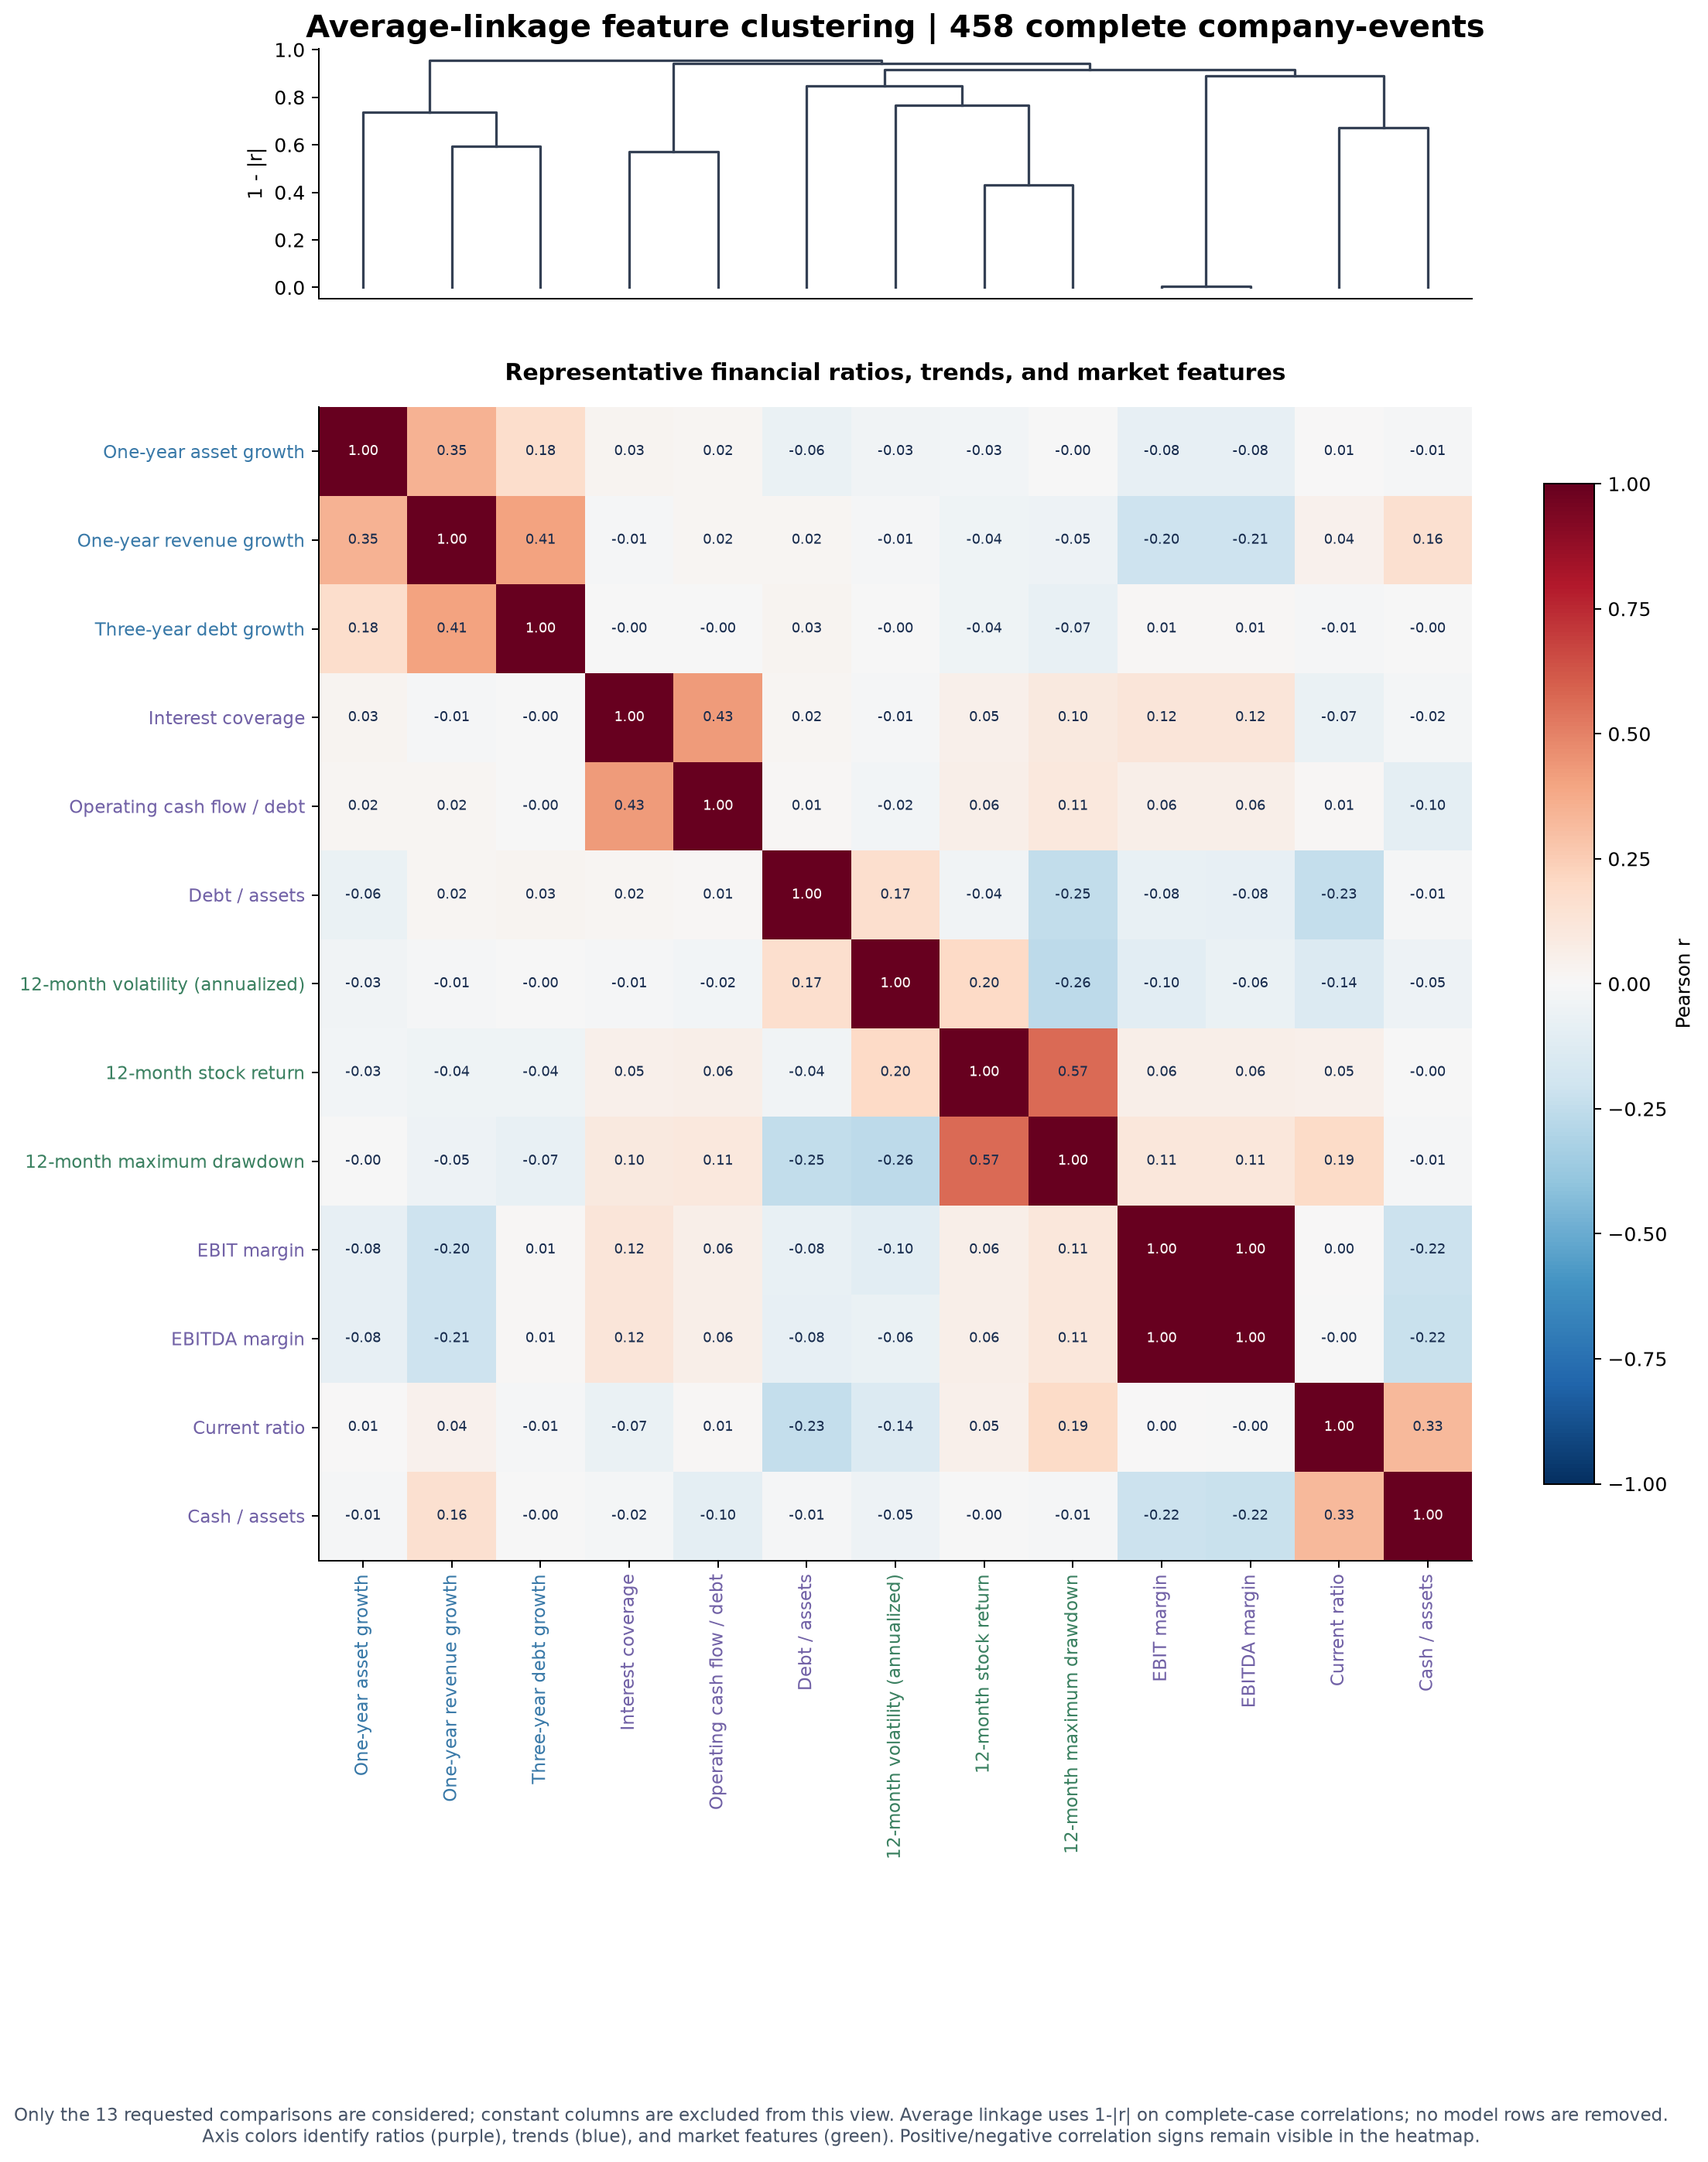

In [8]:
# Average-linkage clustering for a readable 13-feature panel, implemented with NumPy.
# Use complete-case rows only for this correlation display; do not filter model data.
# No undefined correlations are filled in to construct an artificial distance matrix.
def average_linkage(correlation):
    values = np.asarray(correlation, dtype=float)
    if values.ndim != 2 or values.shape[0] != values.shape[1] or not np.isfinite(values).all():
        raise ValueError("Clustering needs a finite square correlation matrix")
    distance = np.clip(1 - np.abs(values), 0, 1)
    n = len(values)
    clusters = {index: [index] for index in range(n)}
    children = {}
    while len(clusters) > 1:
        ids = sorted(clusters)
        choices = [(float(distance[np.ix_(clusters[left], clusters[right])].mean()), left, right)
                   for i, left in enumerate(ids) for right in ids[i+1:]]
        height, left, right = min(choices)
        parent = n + len(children)
        children[parent] = (left, right, height)
        clusters[parent] = clusters.pop(left) + clusters.pop(right)
    root = next(iter(clusters))
    def leaves(node):
        if node < n: return [node]
        left, right, height = children[node]
        return leaves(left) + leaves(right)
    return leaves(root), children, root

selected_columns = list(comparison_features)
complete = model[selected_columns].dropna()
nonconstant = complete.nunique().gt(1)
cluster_columns = nonconstant.index[nonconstant].tolist()
complete = complete[cluster_columns]
fig = plt.figure(figsize=(15, 16))
grid = fig.add_gridspec(2, 1, height_ratios=[1, 5], hspace=.08)
dendrogram_ax = fig.add_subplot(grid[0]); heatmap_ax = fig.add_subplot(grid[1])
if len(complete) >= MIN_CORRELATION_PAIRS and len(cluster_columns) >= 2:
    clustered_corr = complete.corr()
    order, linkage_children, root = average_linkage(clustered_corr.to_numpy())
    ordered_columns = [cluster_columns[i] for i in order]
    ordered_labels = [comparison_features[c] for c in ordered_columns]
    leaf_positions = {leaf: position for position, leaf in enumerate(order)}
    def draw_node(node):
        if node < len(cluster_columns): return float(leaf_positions[node]), 0.
        left, right, height = linkage_children[node]
        left_x, left_height = draw_node(left); right_x, right_height = draw_node(right)
        dendrogram_ax.plot([left_x, left_x, right_x, right_x], [left_height, height, height, right_height], color="#344054", linewidth=1.3)
        return (left_x + right_x) / 2, height
    draw_node(root)
    dendrogram_ax.set_xlim(-.5, len(order)-.5); dendrogram_ax.set_xticks([])
    dendrogram_ax.set_ylabel("1 - |r|")
    dendrogram_ax.set_title(f"Average-linkage feature clustering | {len(complete)} complete company-events", fontsize=16)
    image = correlation_panel(heatmap_ax, clustered_corr.loc[ordered_columns, ordered_columns], ordered_labels, "Representative financial ratios, trends, and market features", annotate=True)
    family_colors = {"derived": "#7161a6", "trend": "#3979a8", "market": "#3a8060"}
    for labels in [heatmap_ax.get_xticklabels(), heatmap_ax.get_yticklabels()]:
        for tick, column in zip(labels, ordered_columns): tick.set_color(family_colors[column.split("_", 1)[0]])
    fig.colorbar(image, ax=heatmap_ax, shrink=.8, label="Pearson r")
else:
    dendrogram_ax.axis("off"); heatmap_ax.axis("off")
    heatmap_ax.text(.5, .5, "Insufficient complete nonconstant observations for clustering;\nno missing correlations were substituted.", ha="center", va="center")
fig.subplots_adjust(left=.25, right=.94, bottom=.25, top=.95)
fig.canvas.draw()
if len(complete) >= MIN_CORRELATION_PAIRS and len(cluster_columns) >= 2:
    heatmap_position = heatmap_ax.get_position()
    dendrogram_position = dendrogram_ax.get_position()
    dendrogram_ax.set_position([heatmap_position.x0, dendrogram_position.y0, heatmap_position.width, dendrogram_position.height])
save_figure(fig, "clustered_feature_correlation_heatmap.png",
            "Only the 13 requested comparisons are considered; constant columns are excluded from this view. Average linkage uses 1-|r| on complete-case correlations; no model rows are removed.\nAxis colors identify ratios (purple), trends (blue), and market features (green). Positive/negative correlation signs remain visible in the heatmap.")
